# ERA5 Tijdreeksmodellering en Risicoclassificatie
## Droogte- en Overstromingsrisico 2000–2025

Dit notebook modelleert vier klimaatindices afkomstig uit de ERA5-dataset
(periode 2000–2025, locatie 42,75°O / 9,25°N, Hoorn van Afrika):

| Index | Beschrijving | Risico-doel |
|-------|-------------|-------------|
| **SPEI** | Standardized Precipitation-Evapotranspiration Index | Droogte |
| **API** | Antecedent Precipitation Index | Droogte |
| **SMI** | Soil Moisture Index | Overstroming |
| **Total Runoff** | Totale afvoer (m/dag) | Overstroming |

**Aanpak**: drie puur-autogressieve tijdreeksmodellen worden gefit op dagelijkse data,
vergeleken en ingezet voor prognoses op **1, 3, 7 en 14 dagen** vooruit.
Geen externe kenmerken (zoals neerslag) worden als invoer gebruikt — alleen
vertraagde waarden van de tijdreeks zelf.  Op basis van de voorspellingen worden
risicoscores berekend met de klassen:
*Laag*, *Gemiddeld*, *Verhoogd*, *Hoog*, *Extreem*.

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

sys.path.insert(0, "..")

from src.modeling import (
    TimeSeriesPreprocessor,
    check_stationarity,
    SARIMAForecaster,
    HoltWintersForecaster,
    RandomForestForecaster,
    XGBoostForecaster,
    LSTMForecaster,
    ProphetForecaster,
    DroughtRiskClassifier,
    FloodRiskClassifier,
    RiskLevel,
)

# ─── Plot-stijl ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

RISK_COLORS = {
    RiskLevel.LOW:      "#2ecc71",
    RiskLevel.MODERATE: "#f1c40f",
    RiskLevel.ELEVATED: "#e67e22",
    RiskLevel.HIGH:     "#e74c3c",
    RiskLevel.EXTREME:  "#8e44ad",
}
RISK_LEGEND = [Patch(color=c, label=r.value) for r, c in RISK_COLORS.items()]

DATA_PATH = "../src/data/processed/era5_2000_2025.parquet"
TEST_START = "2023-01-01"
FORECAST_HORIZONS = [1, 3, 7, 14]  # dagen vooruit

## 1 · Data laden en verkennen

In [2]:
# ── Dagelijkse data (alle modellen werken op dagelijkse resolutie) ─────────
prep_d = TimeSeriesPreprocessor(DATA_PATH, resample_freq=None).load()
df_d = prep_d.df

print(f"Dagelijks: {df_d.shape[0]} rijen  ({df_d.index[0].date()} → {df_d.index[-1].date()})")
df_d[["spei", "api", "smi", "total_ro"]].describe().round(4)

Dagelijks: 9497 rijen  (2000-01-01 → 2025-12-31)


,spei,api,smi,total_ro
count,9497.0000,9497.0000,9497.0000,9497.0000
mean,-0.0547,0.0011,0.2833,0.0000
std,0.9934,0.0016,0.1938,0.0001
min,-4.7534,0.0000,0.0000,0.0000
25%,-0.7316,0.0001,0.1134,0.0000
50%,0.1146,0.0005,0.2444,0.0000
75%,0.6811,0.0014,0.3979,0.0000
max,2.0590,0.0145,1.0000,0.0020


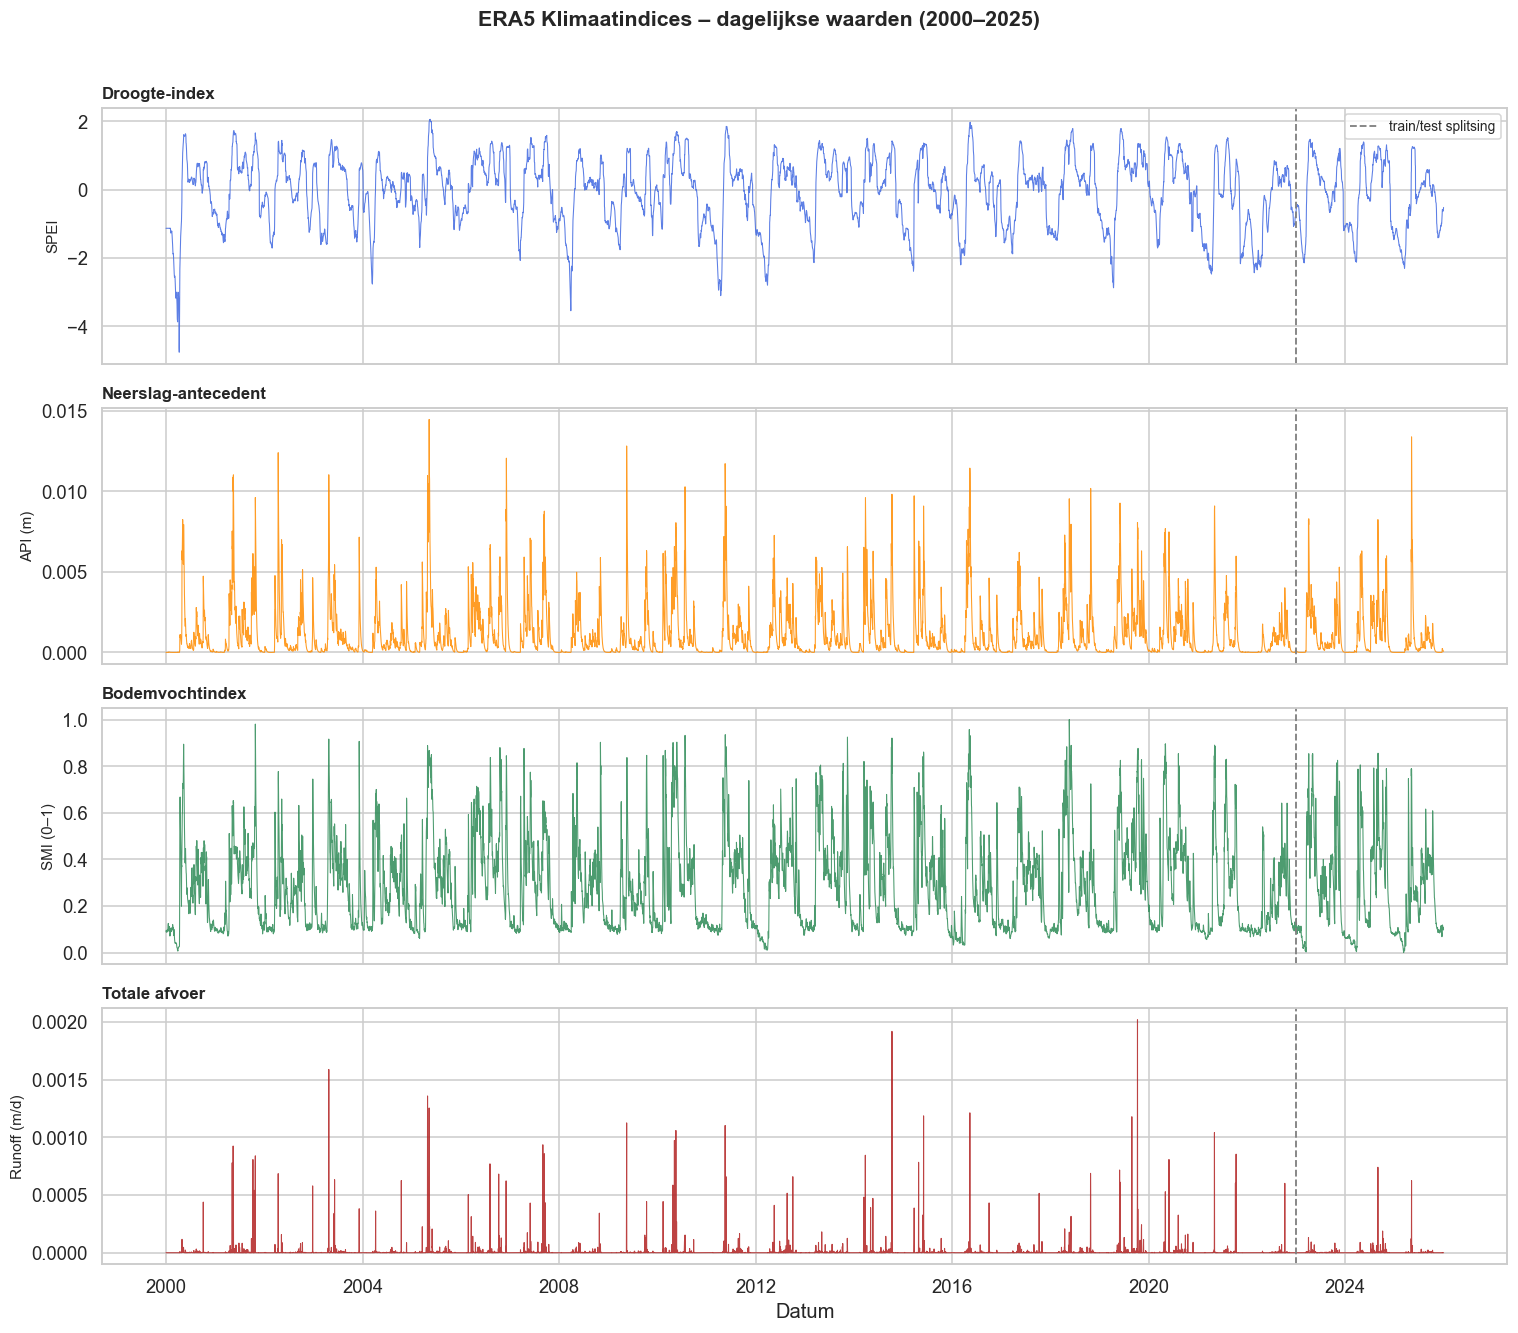

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
pairs = [
    ("spei",     "SPEI",         "royalblue",  "Droogte-index"),
    ("api",      "API (m)",      "darkorange",  "Neerslag-antecedent"),
    ("smi",      "SMI (0–1)",    "seagreen",    "Bodemvochtindex"),
    ("total_ro", "Runoff (m/d)", "firebrick",   "Totale afvoer"),
]
for ax, (col, ylabel, color, title) in zip(axes, pairs):
    ax.plot(df_d.index, df_d[col], lw=0.7, color=color, alpha=0.85)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, loc="left", fontweight="bold")
    ax.axvline(pd.Timestamp(TEST_START), color="grey", ls="--", lw=1.2,
               label="train/test splitsing")

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Datum")
fig.suptitle("ERA5 Klimaatindices – dagelijkse waarden (2000–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("overzicht_tijdreeksen.png", bbox_inches="tight")
plt.show()


## 2 · Stationariteitsanalyse (ADF-test)

Een tijdreeks is *stationair* als gemiddelde en variantie niet veranderen
over de tijd.  De **Augmented Dickey-Fuller (ADF)** test toetst de
nulhypothese H₀: *de reeks bevat een eenheidswortel (non-stationair)*.
Een p-waarde < 0,05 verwerpt H₀ → stationair.

ARIMA kan omgaan met niet-stationariteit via de differentiatieparameter `d`.
Holt-Winters vereist geen stationariteit dankzij de exponentiële afvlakking.

In [4]:
TARGET_COLS = ["spei", "api", "smi", "total_ro"]

rows = []
for col in TARGET_COLS:
    res = check_stationarity(df_d[col])
    rows.append({
        "Index": col.upper(),
        "ADF-statistiek": round(res.statistic, 3),
        "p-waarde": round(res.p_value, 4),
        "Stationair (α=0.05)": "✔ Ja" if res.is_stationary else "✘ Nee",
        "Kritieke waarde 5%": round(res.critical_values["5%"], 3),
    })

pd.DataFrame(rows).set_index("Index")

,ADF-statistiek,p-waarde,Stationair (α=0.05),Kritieke waarde 5%
Index,,,,
SPEI,-9.240,0.0,✔ Ja,-2.862
API,-17.397,0.0,✔ Ja,-2.862
SMI,-11.391,0.0,✔ Ja,-2.862
TOTAL_RO,-23.772,0.0,✔ Ja,-2.862


## 3 · Seizoensanalyse – ACF en PACF

De **Autocorrelatiefunctie (ACF)** toont de correlatie van de dagelijkse reeks met
zichzelf bij verschillende lags (in dagen).  De **Partiële ACF (PACF)** corrigeert
voor tussenliggende lags.  Pieken bij lag 7 (wekelijks) of lag 365 (jaarlijks) wijzen
op seizoenspatronen.  Voor korte-termijn-dagmodellen zijn de eerste 30 lags het meest
informatief voor parameterkeuze.

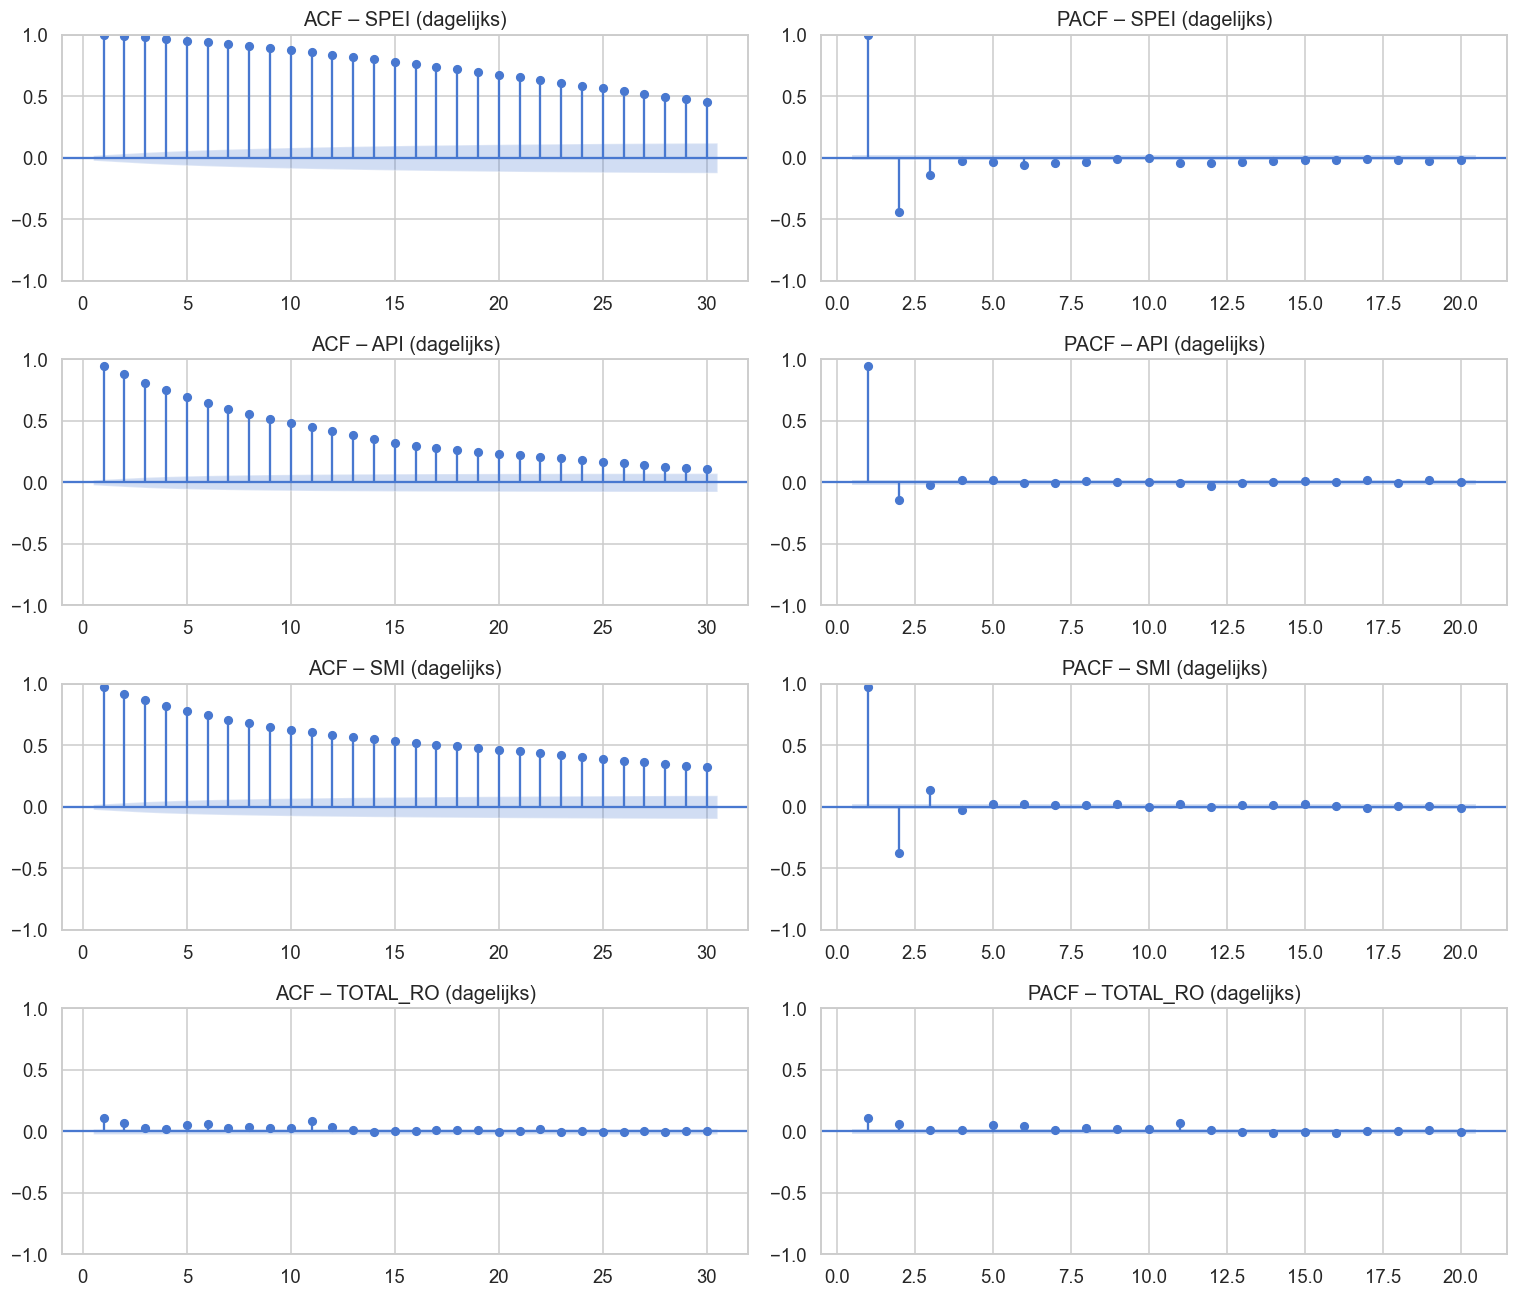

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for i, col in enumerate(TARGET_COLS):
    series = df_d[col].dropna()
    plot_acf(series, lags=30, ax=axes[i, 0],
             title=f"ACF – {col.upper()} (dagelijks)", zero=False)
    plot_pacf(series, lags=20, ax=axes[i, 1],
              title=f"PACF – {col.upper()} (dagelijks)", zero=False, method="ywm")

plt.tight_layout()
plt.savefig("acf_pacf.png", bbox_inches="tight")
plt.show()

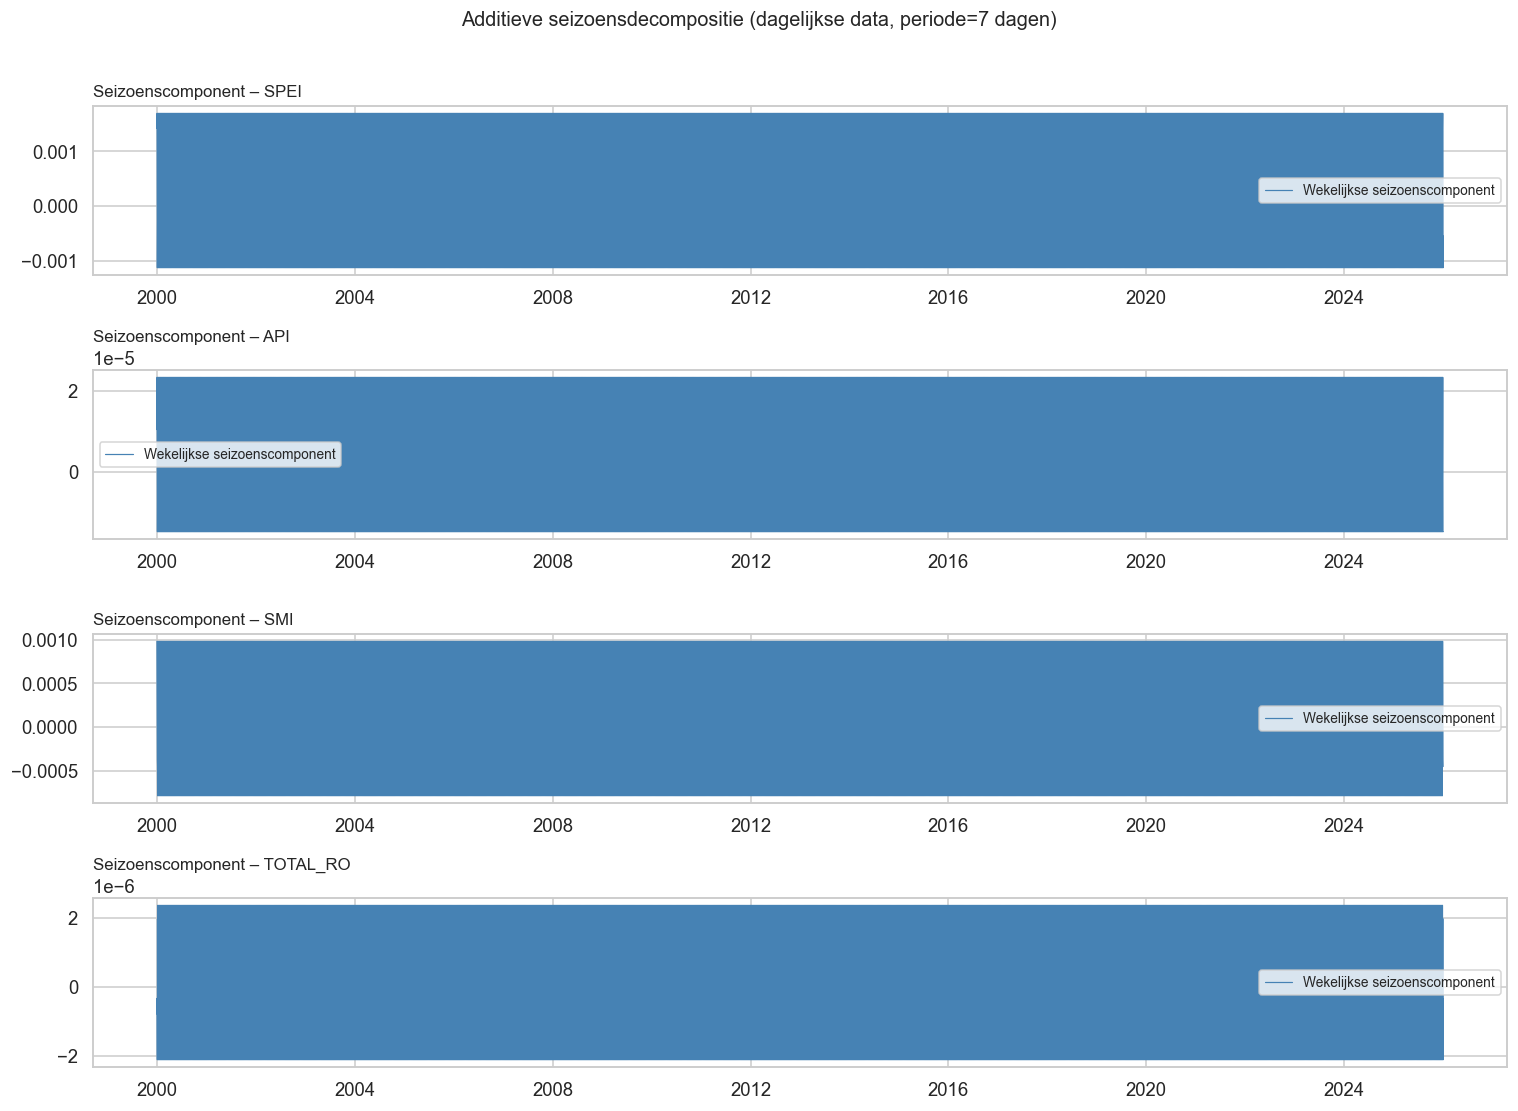

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for ax, col in zip(axes, TARGET_COLS):
    series = df_d[col].dropna()
    result = seasonal_decompose(series, model="additive", period=7)
    ax.plot(result.seasonal, lw=0.8, color="steelblue", label="Wekelijkse seizoenscomponent")
    ax.set_title(f"Seizoenscomponent – {col.upper()}", fontsize=11, loc="left")
    ax.set_xlabel("")
    ax.legend(fontsize=9)

plt.suptitle("Additieve seizoensdecompositie (dagelijkse data, periode=7 dagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("seizoensdecompositie.png", bbox_inches="tight")
plt.show()

## 4 · Train/test splitsing

In [7]:
train_d, test_d = prep_d.train_test_split(TEST_START)

print(f"Dagelijks – train: {len(train_d)} | test: {len(test_d)}")
print(f"Trainingsperiode: {train_d.index[0].date()} → {train_d.index[-1].date()}")
print(f"Testperiode:      {test_d.index[0].date()}  → {test_d.index[-1].date()}")

Dagelijks – train: 8401 | test: 1096
Trainingsperiode: 2000-01-01 → 2022-12-31
Testperiode:      2023-01-01  → 2025-12-31


## 5 · Model 1 – ARIMA (dagelijks, zonder seizoenscomponent)

**AutoRegressive Integrated Moving Average** (ARIMA) combineert auto-regressie (p),
differentiatie (d) en voortschrijdend gemiddelde (q).
Op dagelijkse data is SARIMA met jaarlijks seizoen (s=365) rekenkundig onpraktisch
door het grote aantal te schatten parameters.  ARIMA zonder seizoenscomponent wordt
hier gebruikt als snelle basislijn; de jaarlijkse cyclus wordt gevangen door de
Holt-Winters- en Random Forest-modellen.

Gekozen orde per index:

| Index | (p,d,q) | Reden |
|-------|---------|-------|
| SPEI     | (1,1,1) | Hoge autocorrelatie lag-1, langzaam mean-reverterend |
| API      | (1,1,1) | Vergelijkbaar autocorrelatieprofiel |
| SMI      | (1,1,1) | Sterke persistentie in bodemvocht |
| Total Runoff | (1,1,0) | Sterk asymmetrisch, eenvoudige AR-structuur |

In [8]:
ARIMA_PARAMS = {
    "spei":     {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    "api":      {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    "smi":      {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    "total_ro": {"order": (1, 1, 0), "seasonal_order": (0, 0, 0, 0)},
}

sarima_models = {}
sarima_metrics = {}

for col, params in ARIMA_PARAMS.items():
    print(f"  Fitten ARIMA voor {col.upper()} ...", end=" ")
    model = SARIMAForecaster(target_column=col, **params)
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    sarima_models[col] = model
    sarima_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

  Fitten ARIMA voor SPEI ... RMSE=1.0520  MAE=0.9067  R²=-0.131
  Fitten ARIMA voor API ... RMSE=0.0018  MAE=0.0010  R²=-0.403
  Fitten ARIMA voor SMI ... RMSE=0.2650  MAE=0.1901  R²=-0.695
  Fitten ARIMA voor TOTAL_RO ... RMSE=0.0000  MAE=0.0000  R²=-0.017


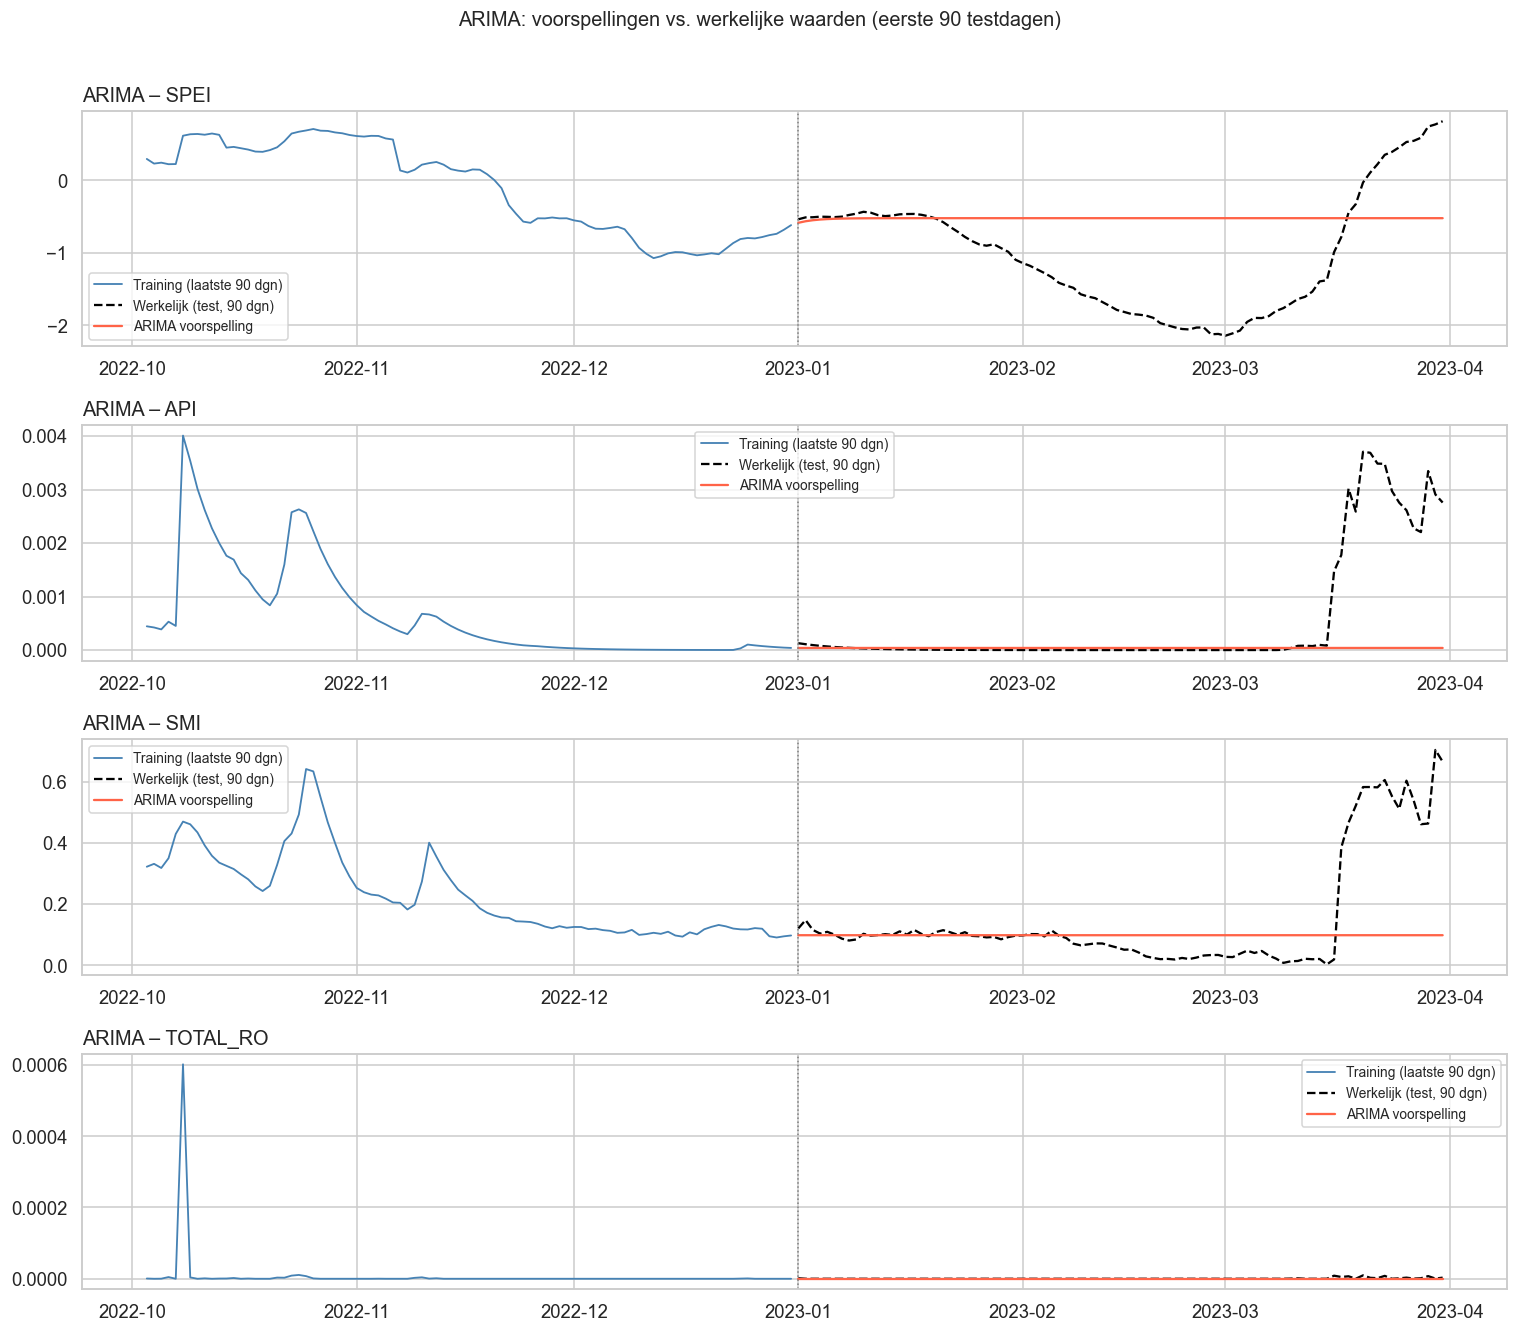

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = sarima_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax.plot(train_d.index[-90:], train_d[col].iloc[-90:],
            color="steelblue", lw=1.2, label="Training (laatste 90 dgn)")
    ax.plot(test_d.index[:90], test_d[col].iloc[:90],
            color="black", lw=1.5, ls="--", label="Werkelijk (test, 90 dgn)")
    ax.plot(test_d.index[:90], pred.iloc[:90],
            color="tomato", lw=1.5, label="ARIMA voorspelling")
    ax.axvline(pd.Timestamp(TEST_START), color="grey", ls=":", lw=1)
    ax.set_title(f"ARIMA – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("ARIMA: voorspellingen vs. werkelijke waarden (eerste 90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("arima_resultaten.png", bbox_inches="tight")
plt.show()

## 6 · Model 2 – Holt-Winters (dagelijks, additief jaarlijks seizoen)

Holt-Winters past exponentiële afvlakking toe voor niveau, trend en een
seizoenscomponent.  Met `seasonal_periods=365` wordt de jaarlijkse droog/natte
cyclus expliciet gemodelleerd — een sterke aanname voor de Hoorn van Afrika.
Het additieve model is geschikt omdat de seizoensamplitude redelijk constant is
over de trainingsperiode.

Het model vereist geen stationariteit en reageert adaptief op recente waarden.

In [10]:
hw_models = {}
hw_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten HoltWinters voor {col.upper()} ...", end=" ")
    model = HoltWintersForecaster(
        target_column=col,
        seasonal_periods=365,
        trend="add",
        seasonal="add",
    )
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    hw_models[col] = model
    hw_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

  Fitten HoltWinters voor SPEI ... RMSE=37.2878  MAE=32.1607  R²=-1420.514
  Fitten HoltWinters voor API ... RMSE=0.0014  MAE=0.0010  R²=0.167
  Fitten HoltWinters voor SMI ... RMSE=0.1989  MAE=0.1405  R²=0.045
  Fitten HoltWinters voor TOTAL_RO ... RMSE=0.0000  MAE=0.0000  R²=-0.503


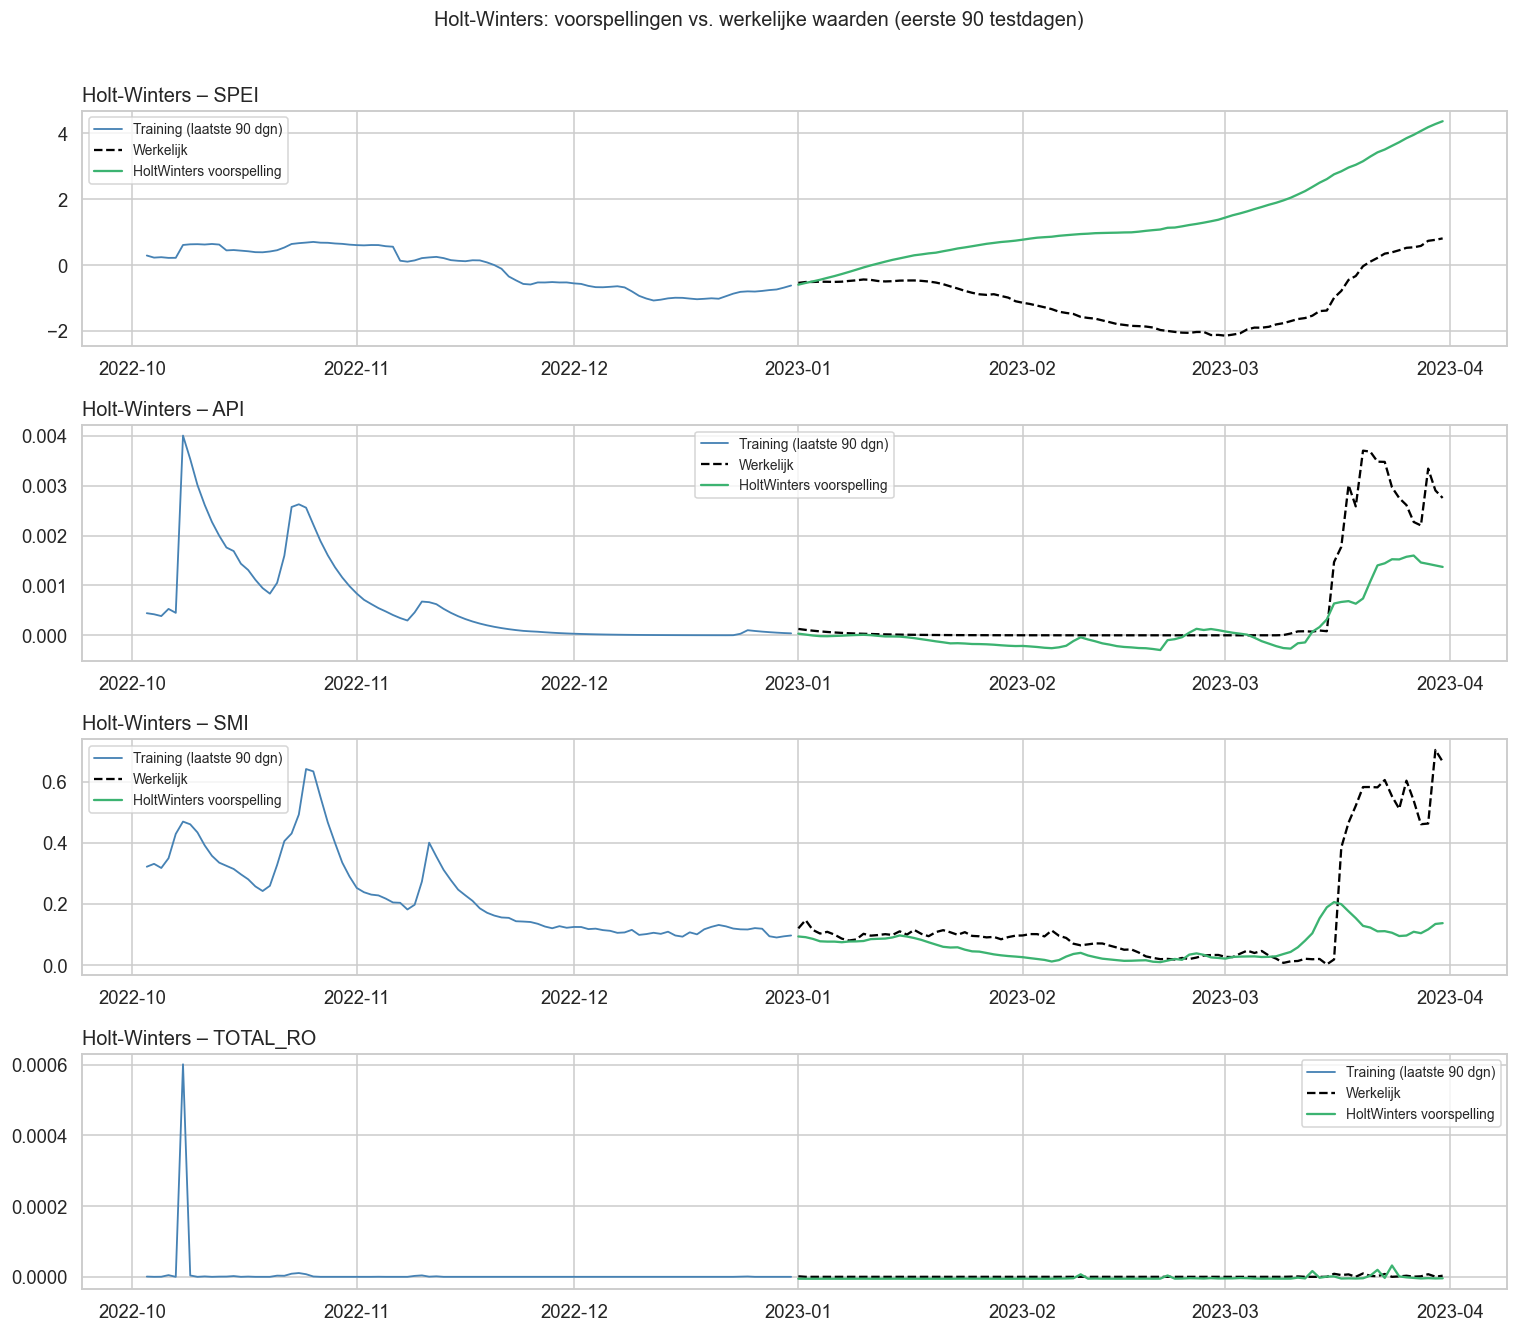

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = hw_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax.plot(train_d.index[-90:], train_d[col].iloc[-90:],
            color="steelblue", lw=1.2, label="Training (laatste 90 dgn)")
    ax.plot(test_d.index[:90], test_d[col].iloc[:90],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(test_d.index[:90], pred.iloc[:90],
            color="mediumseagreen", lw=1.5, label="HoltWinters voorspelling")
    ax.set_title(f"Holt-Winters – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("Holt-Winters: voorspellingen vs. werkelijke waarden (eerste 90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("holtwinters_resultaten.png", bbox_inches="tight")
plt.show()

## 7 · Model 3 – Random Forest (dagelijks, lag-features)

Random Forest transformeert het voorspelprobleem naar gesuperviseerde regressie
door de tijdreeks te voorzien van *lag-features* — vertraagde waarden van de
tijdreeks zelf.  Geen externe kenmerken (neerslag, temperatuur) worden gebruikt.

Lags gebruikt: **[1, 3, 7, 14, 365]** dagen.
- Lag 1–14 vangt de korte-termijn autocorrelatie voor prognoses 1–14 dagen vooruit.
- Lag 365 legt de jaarlijkse seizoenscyclus vast (droog/nat seizoen Hoorn van Afrika).

Cyclische seizoenscoderingen (sin/cos van datum) worden **niet** toegevoegd;
de seizoensinformatie zit volledig in de lagwaarden.

In [12]:
rf_models = {}
rf_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten RandomForest voor {col.upper()} ...", end=" ")
    model = RandomForestForecaster(
        target_column=col,
        lags=[1, 3, 7, 14, 365],
        n_estimators=200,
        random_state=42,
        include_cyclical=False,
    )
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    rf_models[col] = model
    rf_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

  Fitten RandomForest voor SPEI ... RMSE=0.0844  MAE=0.0486  R²=0.993
  Fitten RandomForest voor API ... RMSE=0.0005  MAE=0.0002  R²=0.869
  Fitten RandomForest voor SMI ... RMSE=0.0524  MAE=0.0284  R²=0.934
  Fitten RandomForest voor TOTAL_RO ... RMSE=0.0000  MAE=0.0000  R²=-0.352


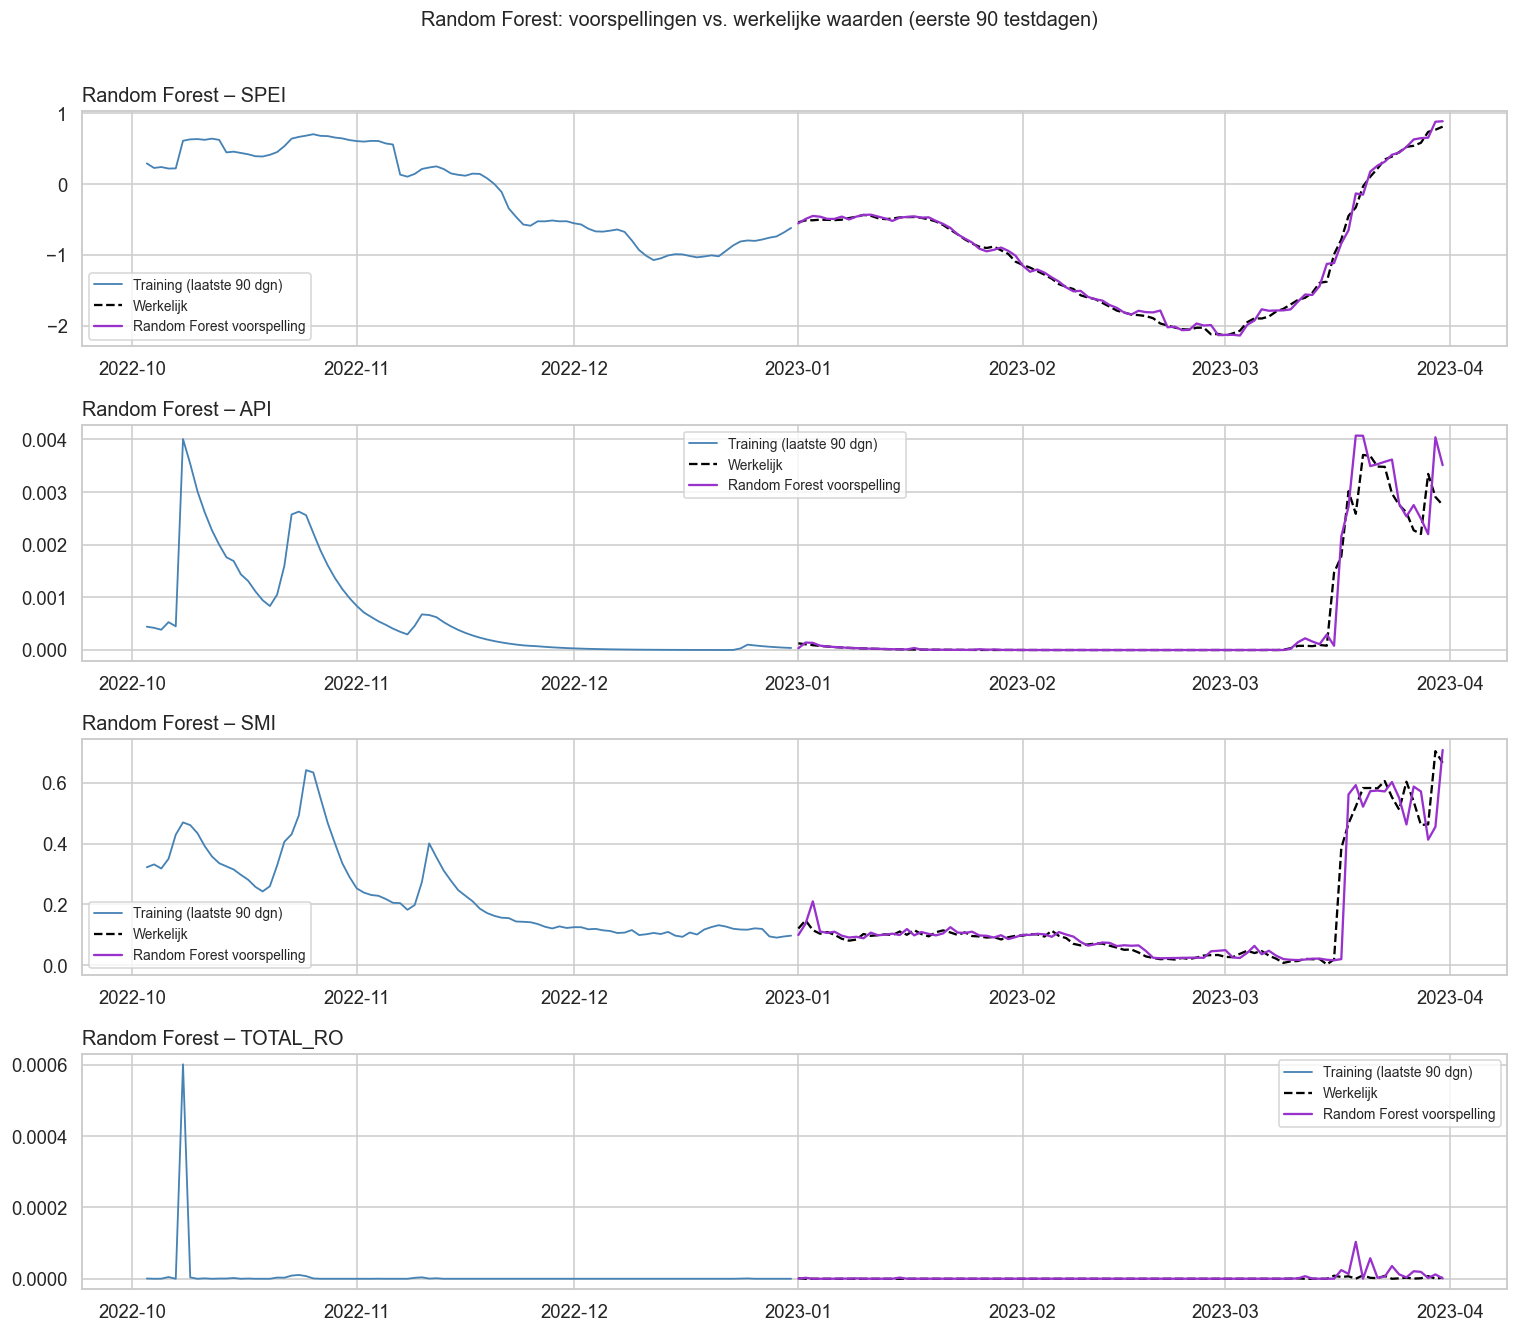

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = rf_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax.plot(train_d.index[-90:], train_d[col].iloc[-90:],
            color="steelblue", lw=1.2, label="Training (laatste 90 dgn)")
    ax.plot(test_d.index[:90], test_d[col].iloc[:90],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(test_d.index[:90], pred.iloc[:90],
            color="darkorchid", lw=1.5, label="Random Forest voorspelling")
    ax.set_title(f"Random Forest – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("Random Forest: voorspellingen vs. werkelijke waarden (eerste 90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("rf_resultaten.png", bbox_inches="tight")
plt.show()

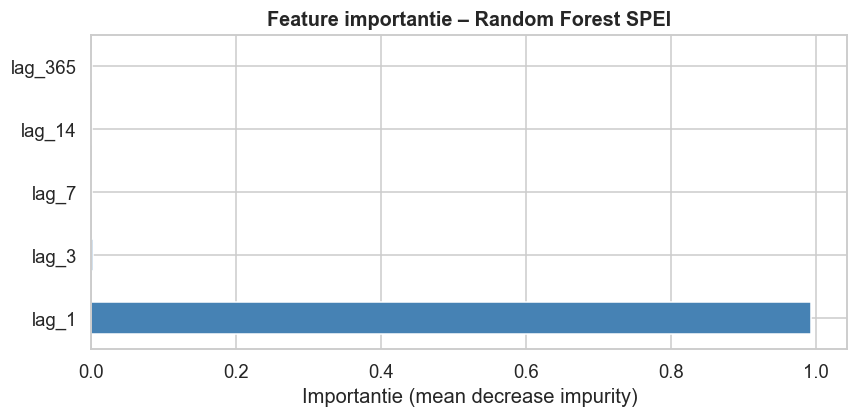

In [14]:
# Feature-importantie voor SPEI (representatief voorbeeld)
fi = rf_models["spei"].feature_importances
fig, ax = plt.subplots(figsize=(8, 4))
fi.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Feature importantie – Random Forest SPEI", fontweight="bold")
ax.set_xlabel("Importantie (mean decrease impurity)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", bbox_inches="tight")
plt.show()


## 8 · Model 4 – XGBoost (dagelijks, gradient boosting)

**XGBoost** gebruikt dezelfde lag-features als Random Forest (`[1, 3, 7, 14, 365]` dagen)
maar bouwt bomen sequentieel: elke boom corrigeert de residu-fout van de vorige.
Dit leidt typisch tot lagere bias op tabellaire tijdreeksdata ten koste van iets
meer rekentijd.

Geen cyclische coderingen (sin/cos van datum) worden toegevoegd — de seizoensinformatie
zit volledig in lag_365.

In [15]:
xgb_models = {}
xgb_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten XGBoost voor {col.upper()} ...", end=" ")
    model = XGBoostForecaster(
        target_column=col,
        lags=[1, 3, 7, 14, 365],
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        include_cyclical=False,
    )
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    xgb_models[col] = model
    xgb_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

  Fitten XGBoost voor SPEI ... RMSE=0.0838  MAE=0.0483  R²=0.993
  Fitten XGBoost voor API ... RMSE=0.0005  MAE=0.0002  R²=0.878
  Fitten XGBoost voor SMI ... RMSE=0.0528  MAE=0.0283  R²=0.933
  Fitten XGBoost voor TOTAL_RO ... RMSE=0.0000  MAE=0.0000  R²=0.000


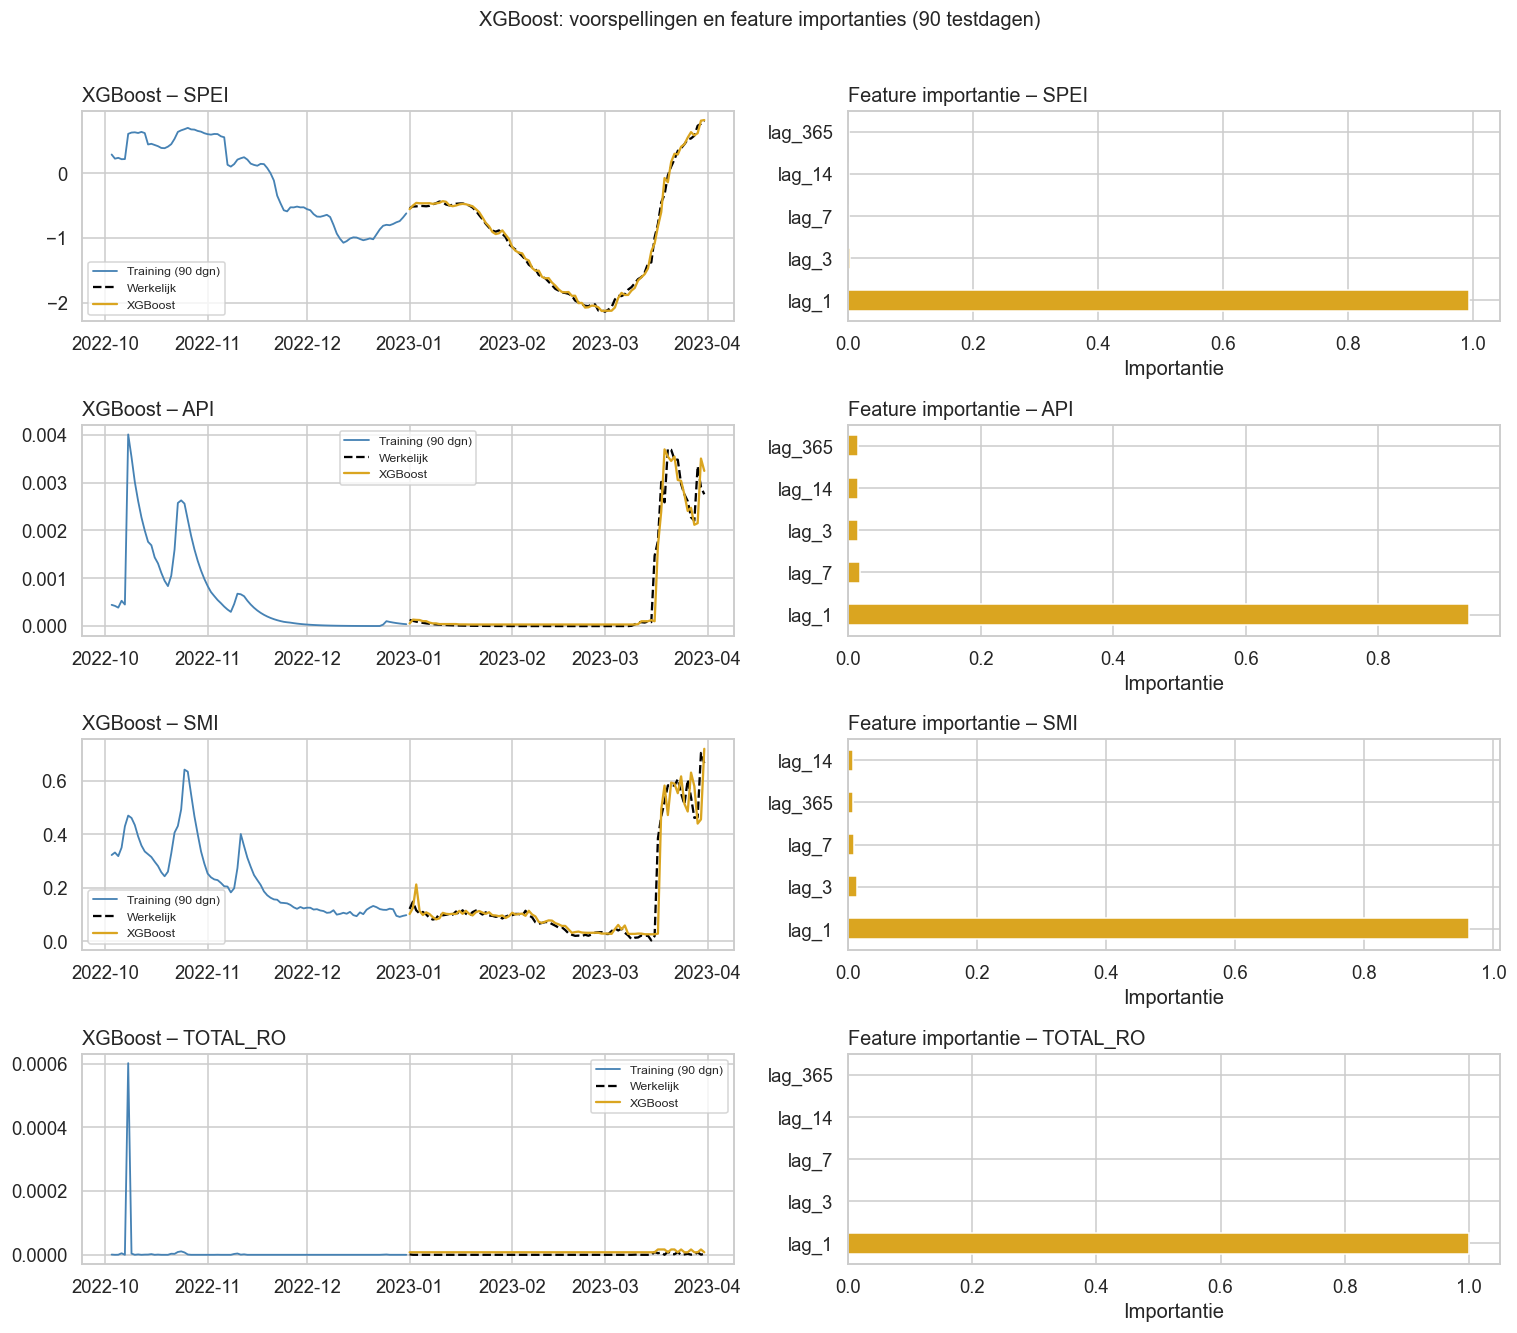

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for i, col in enumerate(TARGET_COLS):
    # Links: voorspelling vs werkelijk
    ax_left = axes[i, 0]
    model = xgb_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax_left.plot(train_d.index[-90:], train_d[col].iloc[-90:],
                 color="steelblue", lw=1.2, label="Training (90 dgn)")
    ax_left.plot(test_d.index[:90], test_d[col].iloc[:90],
                 color="black", lw=1.5, ls="--", label="Werkelijk")
    ax_left.plot(test_d.index[:90], pred.iloc[:90],
                 color="goldenrod", lw=1.5, label="XGBoost")
    ax_left.set_title(f"XGBoost – {col.upper()}", loc="left")
    ax_left.legend(fontsize=8)

    # Rechts: feature importantie
    ax_right = axes[i, 1]
    fi = xgb_models[col].feature_importances
    fi.plot.barh(ax=ax_right, color="goldenrod", edgecolor="white")
    ax_right.set_title(f"Feature importantie – {col.upper()}", loc="left")
    ax_right.set_xlabel("Importantie")

plt.suptitle("XGBoost: voorspellingen en feature importanties (90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("xgb_resultaten.png", bbox_inches="tight")
plt.show()

## 9 · Model 5 – LSTM (dagelijks, sequentieel deep learning)

**Long Short-Term Memory (LSTM)** is een recurrent neuraal netwerk dat langdurige
afhankelijkheden in tijdreeksen leert via gating-mechanismen (input-, forget- en
output-gate).  Het model ziet een venster van de laatste `lookback=30` dagen en
voorspelt de volgende dagwaarde.

Architectuur:
```
Input (30 × 1) → LSTM(64) → Dropout(0.1) → Dense(1)
```

Waarden worden Min-Max genormaliseerd vóór training en getransformeerd
terug naar de oorspronkelijke schaal na voorspelling.

In [17]:
lstm_models = {}
lstm_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten LSTM voor {col.upper()} ...", end=" ")
    model = LSTMForecaster(
        target_column=col,
        lookback=30,
        units=64,
        epochs=20,
        batch_size=64,
        random_state=42,
    )
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    lstm_models[col] = model
    lstm_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

  Fitten LSTM voor SPEI ... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
RMSE=0.1150  MAE=0.0712  R²=0.986
  Fitten LSTM voor API ... RMSE=0.0005  MAE=0.0002  R²=0.879
  Fitten LSTM voor SMI ... RMSE=0.0484  MAE=0.0249  R²=0.943
  Fitten LSTM voor TOTAL_RO ... RMSE=0.0000  MAE=0.0000  R²=0.002


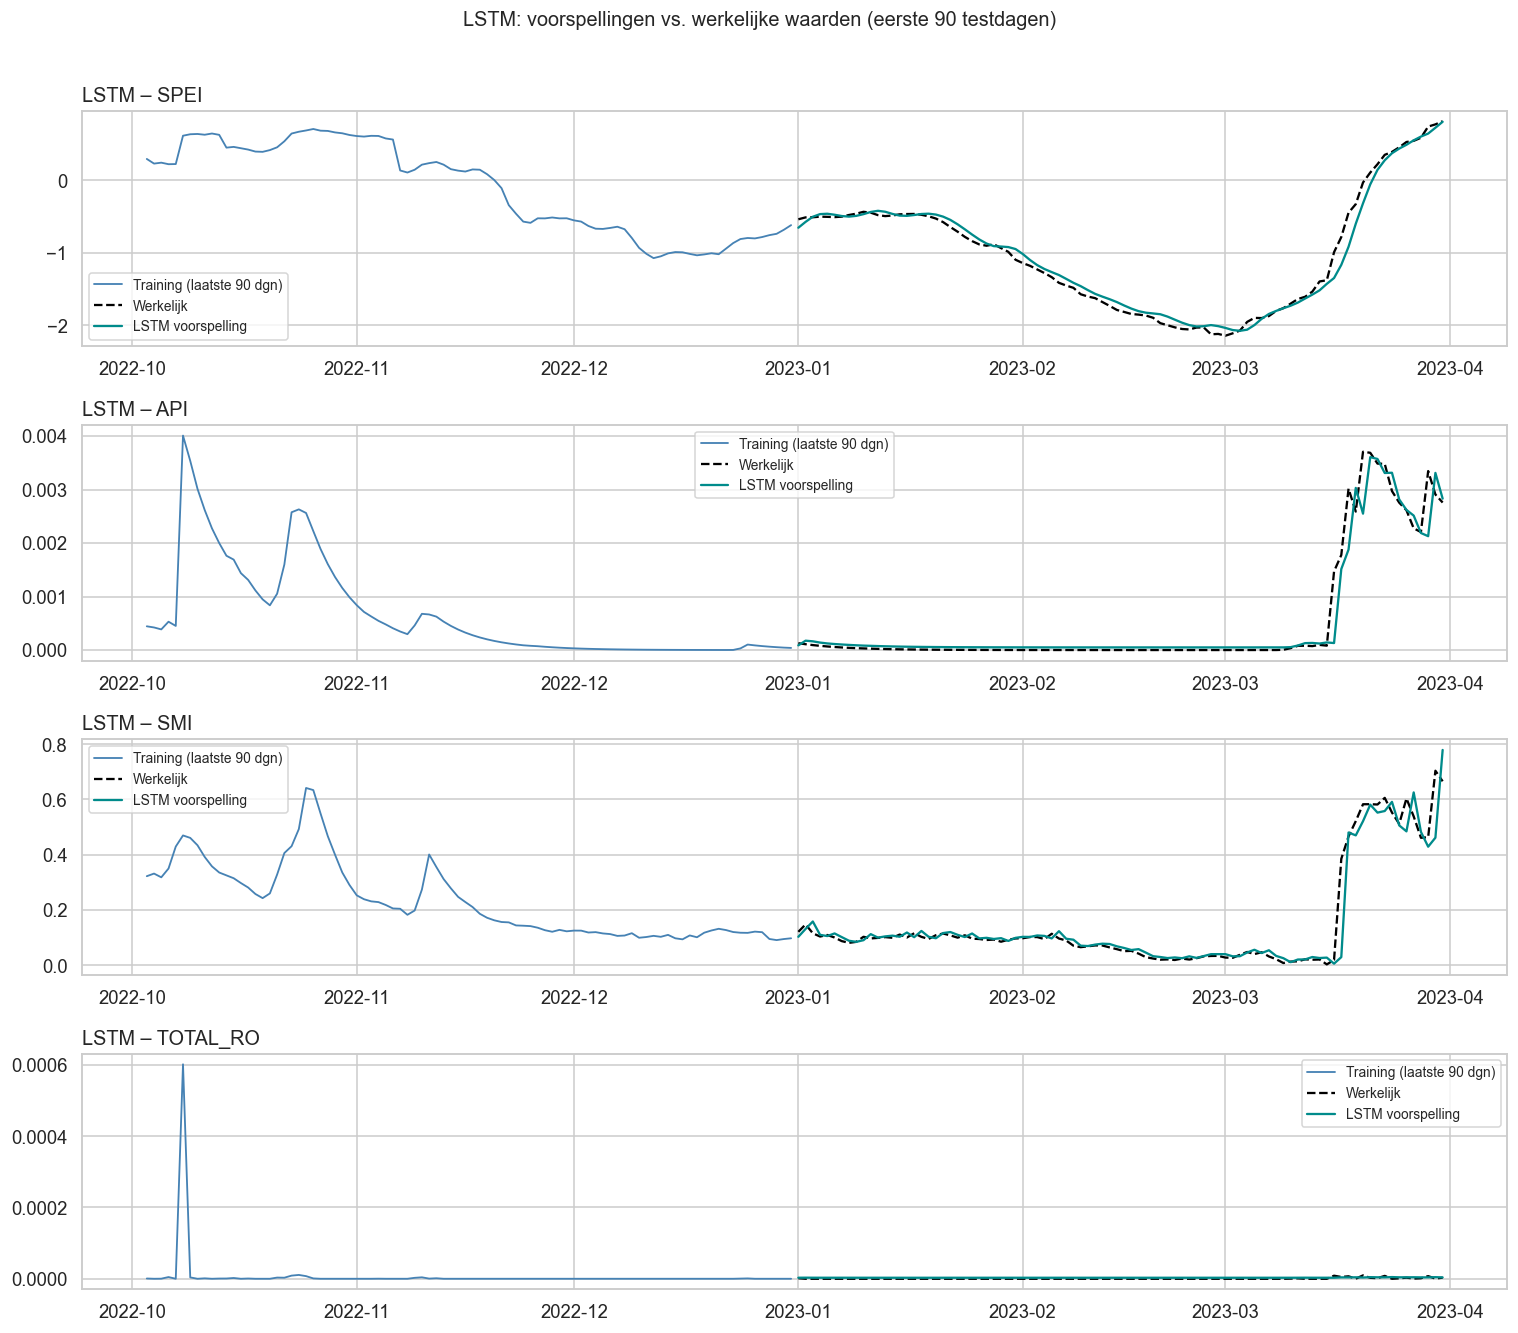

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = lstm_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax.plot(train_d.index[-90:], train_d[col].iloc[-90:],
            color="steelblue", lw=1.2, label="Training (laatste 90 dgn)")
    ax.plot(test_d.index[:90], test_d[col].iloc[:90],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(pred.index[:90], pred.iloc[:90],
            color="darkcyan", lw=1.5, label="LSTM voorspelling")
    ax.set_title(f"LSTM – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("LSTM: voorspellingen vs. werkelijke waarden (eerste 90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("lstm_resultaten.png", bbox_inches="tight")
plt.show()

## 10 · Model 6 – Prophet (dagelijks, trend + jaarlijks seizoen)

**Facebook Prophet** decomponert de tijdreeks in een flexibele trend (stukgewijs
lineair met automatische breekpunten) en een Fourier-seizoenscomponent.
Met `yearly_seasonality=True` leert het model de jaarlijkse droog/nat-cyclus
direct zonder handmatige parameterinput.

Voordelen voor klimaatdata:
- Expliciete modellering van de jaarlijkse cyclus zonder handmatige periodenopgave.
- Robuust voor ontbrekende waarden en uitschieters.
- Geen stationariteitseis.

In [19]:
prophet_models = {}
prophet_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten Prophet voor {col.upper()} ...", end=" ")
    model = ProphetForecaster(
        target_column=col,
        yearly_seasonality=True,
        weekly_seasonality=False,
        changepoint_prior_scale=0.05,
    )
    model.fit(train_d[col])
    pred = model.predict_in_sample(test_d[col])
    metrics = model.evaluate(test_d[col], pred)
    prophet_models[col] = model
    prophet_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")

Importing plotly failed. Interactive plots will not work.


  Fitten Prophet voor SPEI ... 

11:04:38 - cmdstanpy - INFO - Chain [1] start processing
11:04:41 - cmdstanpy - INFO - Chain [1] done processing


RMSE=0.8321  MAE=0.6073  R²=0.292
  Fitten Prophet voor API ... 

11:04:42 - cmdstanpy - INFO - Chain [1] start processing
11:04:44 - cmdstanpy - INFO - Chain [1] done processing


RMSE=0.0014  MAE=0.0008  R²=0.198
  Fitten Prophet voor SMI ... 

11:04:45 - cmdstanpy - INFO - Chain [1] start processing
11:04:47 - cmdstanpy - INFO - Chain [1] done processing


RMSE=0.1649  MAE=0.1115  R²=0.343
  Fitten Prophet voor TOTAL_RO ... 

11:04:48 - cmdstanpy - INFO - Chain [1] start processing
11:04:49 - cmdstanpy - INFO - Chain [1] done processing


RMSE=0.0000  MAE=0.0000  R²=-0.048


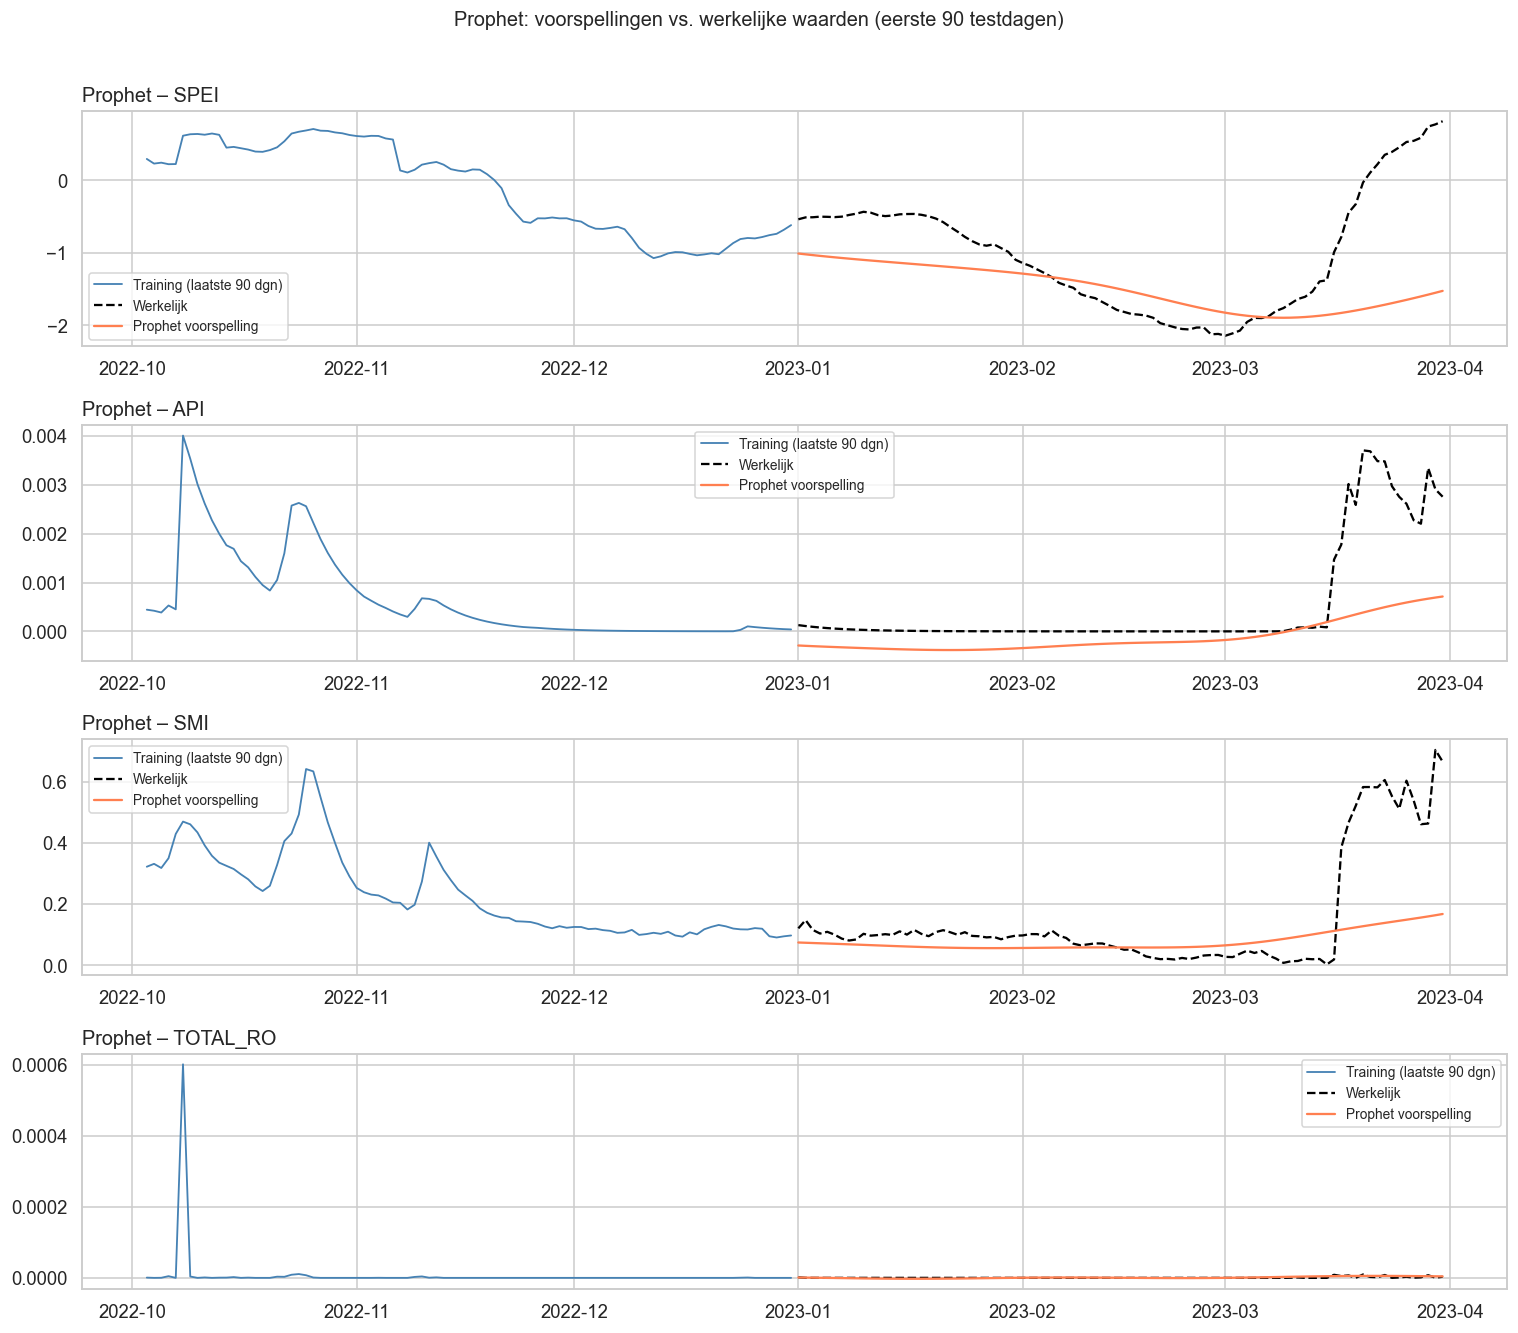

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = prophet_models[col]
    pred  = model.predict_in_sample(test_d[col])
    ax.plot(train_d.index[-90:], train_d[col].iloc[-90:],
            color="steelblue", lw=1.2, label="Training (laatste 90 dgn)")
    ax.plot(test_d.index[:90], test_d[col].iloc[:90],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(test_d.index[:90], pred.iloc[:90],
            color="coral", lw=1.5, label="Prophet voorspelling")
    ax.set_title(f"Prophet – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("Prophet: voorspellingen vs. werkelijke waarden (eerste 90 testdagen)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("prophet_resultaten.png", bbox_inches="tight")
plt.show()

## 11 · Baselinecomparisatie – alle 6 modellen

Alle zes baseline-modellen worden op dezelfde testset (2023–2025) vergeleken.
Dit overzicht bepaalt welk model per klimaatindex als vertrekpunt wordt meegenomen
naar de foundation model-fase.

In [21]:
rows = []
for col in TARGET_COLS:
    for model_name, metrics_dict in [
        ("ARIMA",        sarima_metrics),
        ("Holt-Winters", hw_metrics),
        ("RandomForest", rf_metrics),
        ("XGBoost",      xgb_metrics),
        ("LSTM",         lstm_metrics),
        ("Prophet",      prophet_metrics),
    ]:
        m = metrics_dict[col]
        rows.append({
            "Index": col.upper(),
            "Model": model_name,
            "RMSE": round(m.rmse, 5),
            "MAE":  round(m.mae, 5),
            "R²":   round(m.r2, 3),
        })

comparison_df = pd.DataFrame(rows).set_index(["Index", "Model"])
comparison_df.style.highlight_min(subset=["RMSE", "MAE"], color="lightgreen") \
                   .highlight_max(subset=["R²"],           color="lightgreen")

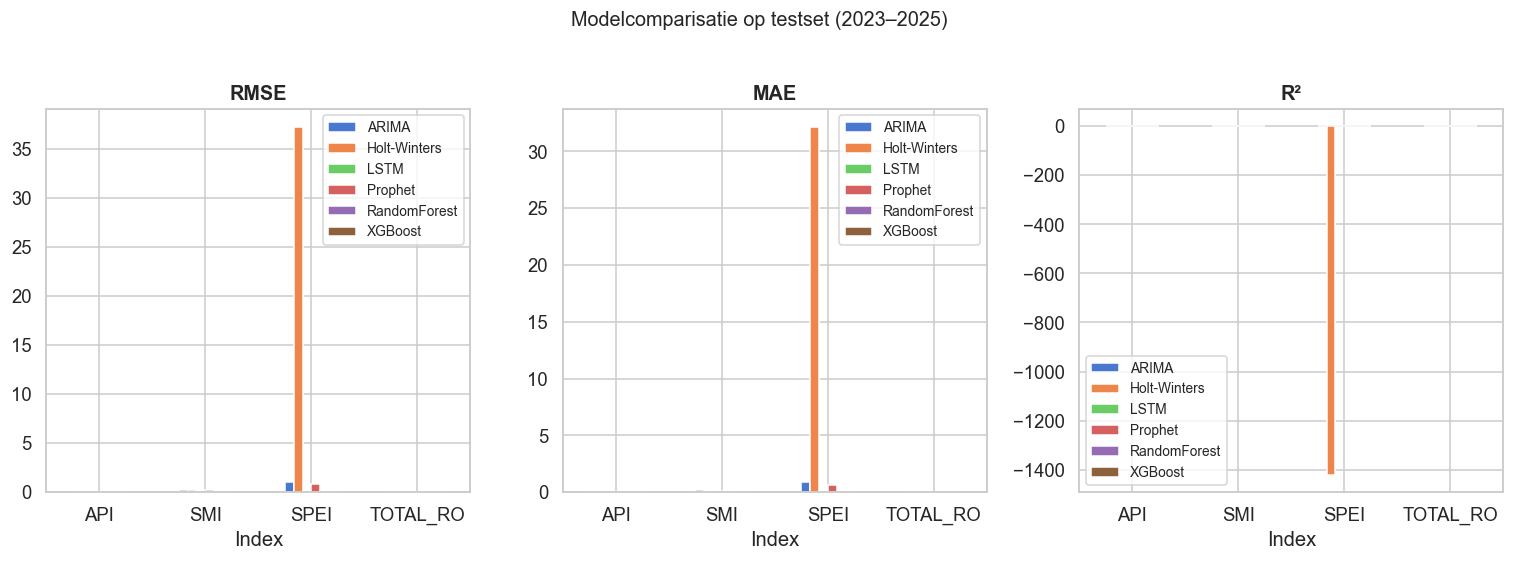

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "R²"]):
    pivot = comparison_df[metric].unstack("Model")
    pivot.plot.bar(ax=ax, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("Index")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Modelcomparisatie op testset (2023–2025)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("model_vergelijking.png", bbox_inches="tight")
plt.show()


In [23]:
# Selecteer het beste model per index op basis van RMSE
best_models = {}
model_lookup = {
    "ARIMA":        sarima_models,
    "Holt-Winters": hw_models,
    "RandomForest": rf_models,
    "XGBoost":      xgb_models,
    "LSTM":         lstm_models,
    "Prophet":      prophet_models,
}

for col in TARGET_COLS:
    col_df = comparison_df.loc[col.upper(), "RMSE"]
    best_name = col_df.idxmin()
    print(f"{col.upper():12s} → beste baseline: {best_name}  "
          f"(RMSE={col_df[best_name]:.5f})")
    best_models[col] = model_lookup[best_name][col]

SPEI         → beste baseline: XGBoost  (RMSE=0.08377)
API          → beste baseline: XGBoost  (RMSE=0.00053)
SMI          → beste baseline: LSTM  (RMSE=0.04841)
TOTAL_RO     → beste baseline: ARIMA  (RMSE=0.00003)


## 12 · Droogterisicoclassificatie

De `DroughtRiskClassifier` combineert SPEI en API:

1. **SPEI** (primair) – geclassificeerd conform McKee et al. (1993):
   - ≥ −0,5 → *Laag*  | −1,0 tot −0,5 → *Gemiddeld*
   - −1,5 tot −1,0 → *Verhoogd* | −2,0 tot −1,5 → *Hoog* | < −2,0 → *Extreem*
2. **API** (modificator) – als API < 25e percentiel wordt het risiconiveau één klasse verhoogd.

In [24]:
drought_clf = DroughtRiskClassifier(api_low_percentile=0.25)
drought_clf.fit(train_d)

# Classificeer de volledige dagelijkse reeks
drought_risk_daily = drought_clf.classify(df_d)

# Overzicht per risicoklasse
counts = drought_risk_daily.value_counts()
pct    = (counts / len(drought_risk_daily) * 100).round(1)
summary = pd.DataFrame({"Dagen": counts, "%": pct})
summary.index = [r.value for r in summary.index]
print("Droogterisico – verdeling over volledige periode:")
summary


Droogterisico – verdeling over volledige periode:


,Dagen,%
Laag risico,6243,65.7
Verhoogd risico,904,9.5
Hoog risico,895,9.4
Gemiddeld risico,729,7.7
Extreem risico,726,7.6


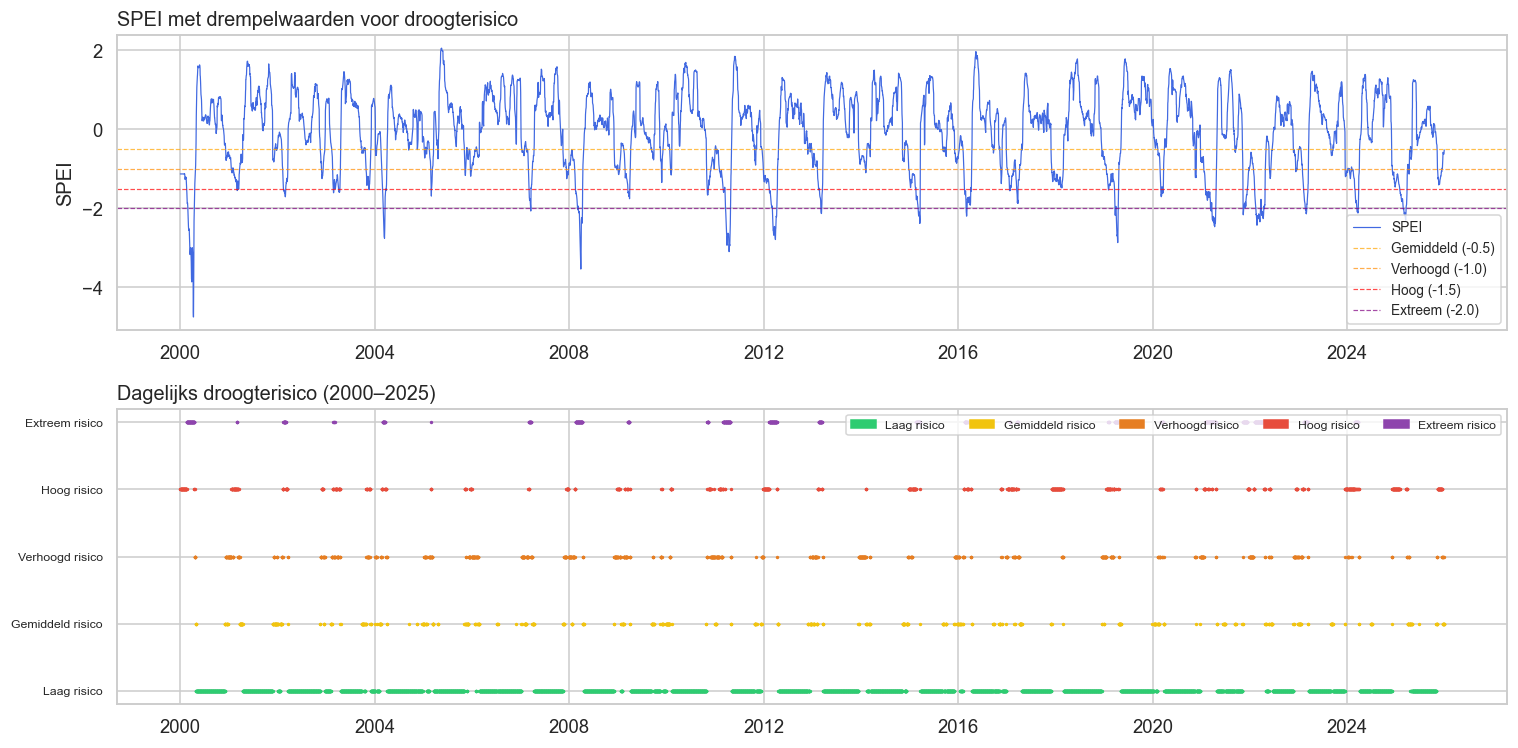

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Tijdreeks met achtergrondkleuren
ax = axes[0]
ax.plot(df_d.index, df_d["spei"], lw=0.8, color="royalblue", label="SPEI")
ax.axhline(-0.5, color="orange",  ls="--", lw=0.8, alpha=0.7)
ax.axhline(-1.0, color="darkorange", ls="--", lw=0.8, alpha=0.7)
ax.axhline(-1.5, color="red", ls="--", lw=0.8, alpha=0.7)
ax.axhline(-2.0, color="purple", ls="--", lw=0.8, alpha=0.7)
ax.set_ylabel("SPEI")
ax.set_title("SPEI met drempelwaarden voor droogterisico", loc="left")
ax.legend(["SPEI", "Gemiddeld (-0.5)", "Verhoogd (-1.0)",
           "Hoog (-1.5)", "Extreem (-2.0)"], fontsize=9)

# Risico als numerieke tijdreeks
ax2 = axes[1]
risk_numeric = drought_risk_daily.apply(lambda r: r.numeric)
# Kleur elk punt op basis van risiconiveau
for level in RiskLevel:
    mask = drought_risk_daily == level
    ax2.scatter(
        df_d.index[mask], risk_numeric[mask],
        s=1.5, color=RISK_COLORS[level], label=level.value
    )
ax2.set_yticks(range(5))
ax2.set_yticklabels([r.value for r in RiskLevel], fontsize=8)
ax2.set_title("Dagelijks droogterisico (2000–2025)", loc="left")
ax2.legend(handles=RISK_LEGEND, fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("droogterisico_historisch.png", bbox_inches="tight")
plt.show()


## 13 · Overstromingsrisicoclassificatie

De `FloodRiskClassifier` combineert SMI en Total Runoff via een gewogen
composietscore:

    flood_score = 0,5 × norm_SMI + 0,5 × norm_total_ro

Beide indicatoren worden Min-Max genormaliseerd op de trainingsdata.
Risicodrempels worden afgeleid van de empirische percentielen (40e, 60e, 75e, 90e).

In [26]:
flood_clf = FloodRiskClassifier(smi_weight=0.5, runoff_weight=0.5)
flood_clf.fit(train_d)

flood_risk_daily = flood_clf.classify(df_d)

counts_f = flood_risk_daily.value_counts()
pct_f    = (counts_f / len(flood_risk_daily) * 100).round(1)
summary_f = pd.DataFrame({"Dagen": counts_f, "%": pct_f})
summary_f.index = [r.value for r in summary_f.index]
print("Overstromingsrisico – verdeling over volledige periode:")
summary_f


Overstromingsrisico – verdeling over volledige periode:


,Dagen,%
Laag risico,3846,40.5
Gemiddeld risico,1870,19.7
Hoog risico,1425,15.0
Verhoogd risico,1402,14.8
Extreem risico,954,10.0


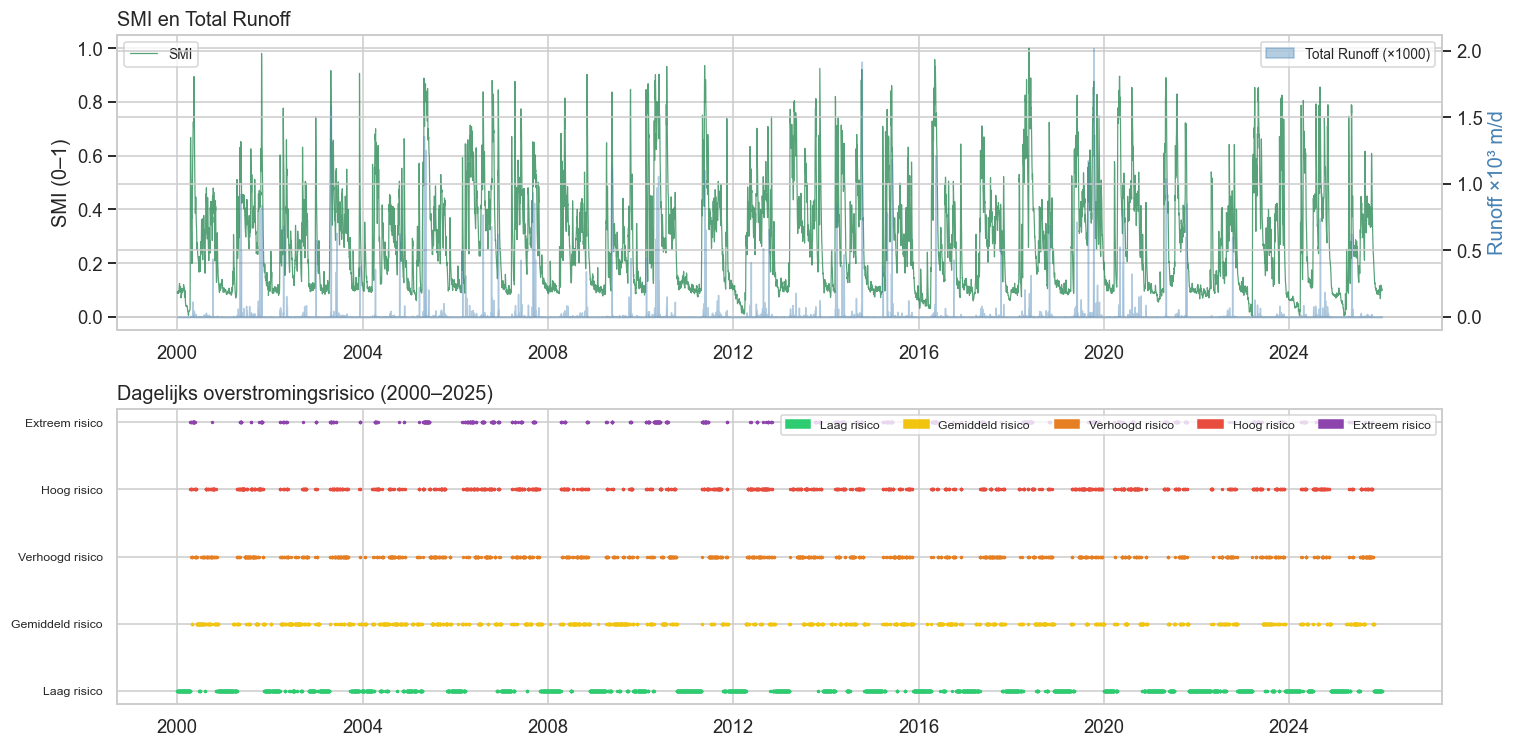

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# SMI tijdreeks
ax = axes[0]
ax.plot(df_d.index, df_d["smi"], lw=0.8, color="seagreen", label="SMI", alpha=0.8)
ax2b = ax.twinx()
ax2b.fill_between(df_d.index, df_d["total_ro"] * 1000, alpha=0.4,
                  color="steelblue", label="Total Runoff (×1000)")
ax2b.set_ylabel("Runoff ×10³ m/d", color="steelblue")
ax.set_ylabel("SMI (0–1)")
ax.set_title("SMI en Total Runoff", loc="left")
ax.legend(loc="upper left", fontsize=9)
ax2b.legend(loc="upper right", fontsize=9)

# Risico
ax3 = axes[1]
risk_numeric_f = flood_risk_daily.apply(lambda r: r.numeric)
for level in RiskLevel:
    mask = flood_risk_daily == level
    ax3.scatter(
        df_d.index[mask], risk_numeric_f[mask],
        s=1.5, color=RISK_COLORS[level], label=level.value
    )
ax3.set_yticks(range(5))
ax3.set_yticklabels([r.value for r in RiskLevel], fontsize=8)
ax3.set_title("Dagelijks overstromingsrisico (2000–2025)", loc="left")
ax3.legend(handles=RISK_LEGEND, fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("overstromingsrisico_historisch.png", bbox_inches="tight")
plt.show()


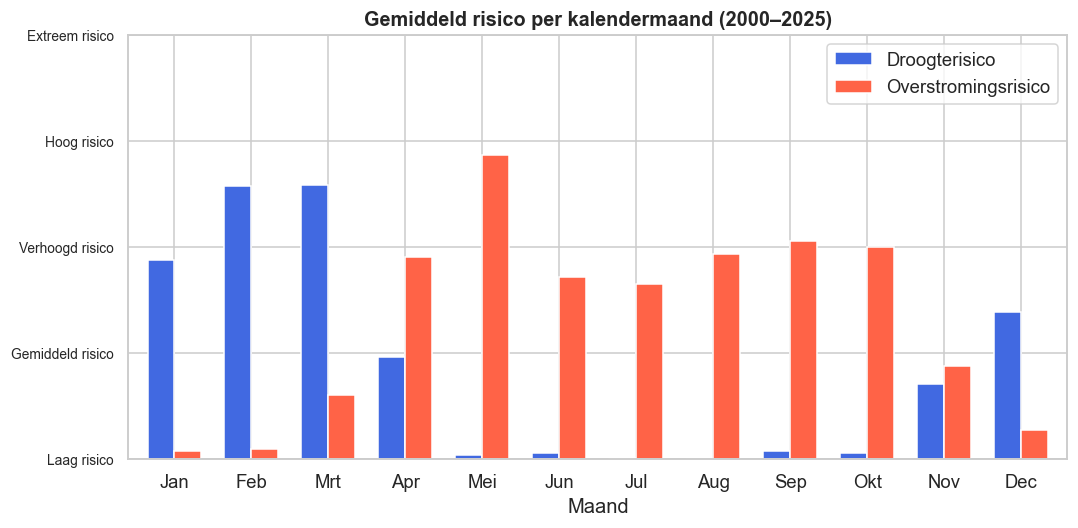

In [28]:
# Gemiddeld risico per maand (numeriek)
df_risk = pd.DataFrame({
    "drought":  drought_risk_daily.apply(lambda r: r.numeric),
    "flood":    flood_risk_daily.apply(lambda r: r.numeric),
    "month":    df_d.index.month,
})
monthly_risk = df_risk.groupby("month")[["drought", "flood"]].mean()
monthly_risk.index = ["Jan","Feb","Mrt","Apr","Mei","Jun",
                       "Jul","Aug","Sep","Okt","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
monthly_risk.plot.bar(ax=ax, color=["royalblue", "tomato"],
                      edgecolor="white", width=0.7)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=9)
ax.set_xlabel("Maand")
ax.set_title("Gemiddeld risico per kalendermaand (2000–2025)", fontweight="bold")
ax.legend(["Droogterisico", "Overstromingsrisico"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("seizoensrisico.png", bbox_inches="tight")
plt.show()


## 14 · Toekomstprognose – 1, 3, 7 en 14 dagen vooruit

Het beste baseline-model per index wordt ingezet voor een dagelijkse prognose van
**14 stappen** vooruit.  Uit die prognose worden de waarden op de vier specifieke
horizonnen geëxtraheerd:

| Horizon | Beschrijving |
|---------|-------------|
| **+1 dag** | Morgen – hoge betrouwbaarheid |
| **+3 dagen** | 3-daagse outlook |
| **+7 dagen** | Weekprognose |
| **+14 dagen** | 2-wekenprognose – grotere onzekerheid |

> **Volgende stap**: de gelabelde tijdreeksdata en de baseline-prestaties dienen als
> vertrekpunt voor het trainen van een **foundation model** (bijv. Chronos, TimesFM,
> of een custom Transformer) dat alle klimaatindices tegelijk modelleert.

In [29]:
# Genereer 14-daagse prognose met het beste model per index
future_14 = {}
for col in TARGET_COLS:
    future_14[col] = best_models[col].predict(steps=14)

future_df = pd.DataFrame(future_14)
future_df.index.name = "date"

# Extraheer de vier specifieke horizonnen (0-gebaseerde indexering: dag 1 = index 0)
HORIZON_IDX = {h: h - 1 for h in FORECAST_HORIZONS}  # {1:0, 3:2, 7:6, 14:13}

horizon_rows = []
for h, idx in HORIZON_IDX.items():
    row = {"Horizon": f"+{h} dag{'en' if h > 1 else ''}",
           "Datum": future_df.index[idx].strftime("%Y-%m-%d")}
    for col in TARGET_COLS:
        row[col.upper()] = round(future_df[col].iloc[idx], 5)
    horizon_rows.append(row)

horizon_table = pd.DataFrame(horizon_rows).set_index("Horizon")
print(f"Prognoseperiode: {future_df.index[0].date()} → {future_df.index[-1].date()}")
horizon_table

Prognoseperiode: 2023-01-01 → 2023-01-14


,Datum,SPEI,API,SMI,TOTAL_RO
Horizon,,,,,
+1 dag,2023-01-01,-0.55219,0.00005,0.10245,0.0
+3 dagen,2023-01-03,-0.45534,0.00007,0.11467,0.0
+7 dagen,2023-01-07,-0.37716,0.00019,0.13553,0.0
+14 dagen,2023-01-14,-0.39174,0.00130,0.16040,0.0


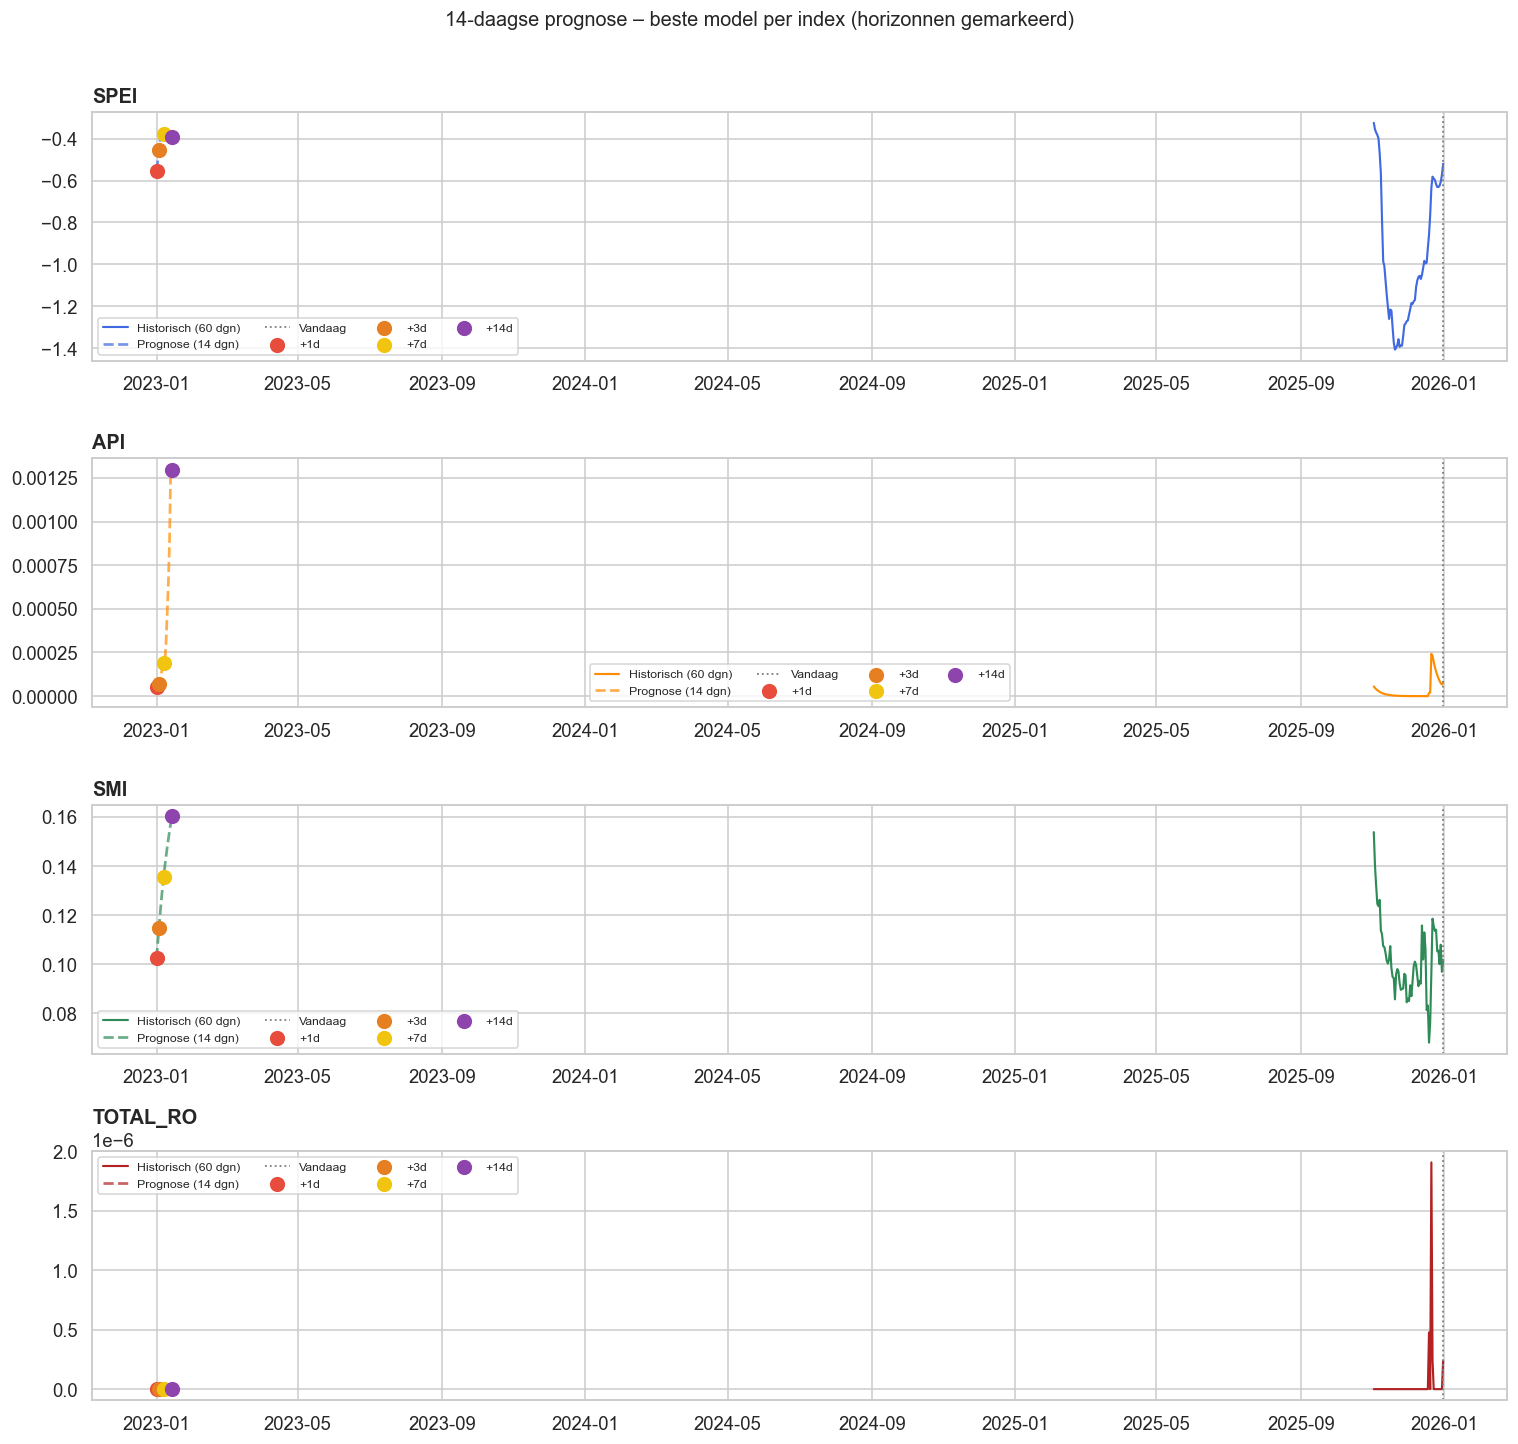

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=False)
COLORS = ["royalblue", "darkorange", "seagreen", "firebrick"]
MARKER_COLORS = {"1": "#e74c3c", "3": "#e67e22", "7": "#f1c40f", "14": "#8e44ad"}

for ax, col, color in zip(axes, TARGET_COLS, COLORS):
    hist = df_d[col].iloc[-60:]
    pred = future_df[col]
    ax.plot(hist.index, hist, color=color, lw=1.4, label="Historisch (60 dgn)")
    ax.plot(pred.index, pred, color=color, lw=1.8, ls="--", alpha=0.7, label="Prognose (14 dgn)")
    ax.axvline(df_d.index[-1], color="grey", ls=":", lw=1.2, label="Vandaag")

    # Markeer de vier horizonnen
    for h, idx in HORIZON_IDX.items():
        ax.scatter(pred.index[idx], pred.iloc[idx],
                   s=80, zorder=5, color=MARKER_COLORS[str(h)],
                   label=f"+{h}d")

    ax.set_title(col.upper(), loc="left", fontweight="bold")
    ax.legend(fontsize=8, ncol=4)

plt.suptitle("14-daagse prognose – beste model per index (horizonnen gemarkeerd)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("toekomstprognose.png", bbox_inches="tight")
plt.show()

In [31]:
# Risicoclassificatie op elk van de vier horizonnen
risk_rows = []
for h, idx in HORIZON_IDX.items():
    spei_val = future_df["spei"].iloc[idx]
    api_val  = future_df["api"].iloc[idx]
    smi_val  = future_df["smi"].iloc[idx]
    ro_val   = future_df["total_ro"].iloc[idx]

    drought_risk = drought_clf.classify_from_predictions(
        spei_pred=pd.Series([spei_val]),
        api_pred=pd.Series([api_val]),
    ).iloc[0]

    flood_risk = flood_clf.classify_from_predictions(
        smi_pred=pd.Series([smi_val]),
        total_ro_pred=pd.Series([ro_val]),
    ).iloc[0]

    risk_rows.append({
        "Horizon":            f"+{h} dag{'en' if h > 1 else ''}",
        "Datum":              future_df.index[idx].strftime("%Y-%m-%d"),
        "SPEI (pred)":        round(spei_val, 3),
        "API (pred)":         round(api_val, 6),
        "Droogterisico":      drought_risk.value,
        "SMI (pred)":         round(smi_val, 3),
        "Runoff (pred)":      round(ro_val, 8),
        "Overstromingsrisico": flood_risk.value,
    })

risk_forecast_df = pd.DataFrame(risk_rows).set_index("Horizon")
print("Risicoclassificatie per prognose-horizon:")
risk_forecast_df

Risicoclassificatie per prognose-horizon:


,Datum,SPEI (pred),API (pred),Droogterisico,SMI (pred),Runoff (pred),Overstromingsrisico
Horizon,,,,,,,
+1 dag,2023-01-01,-0.552,0.000054,Verhoogd risico,0.102,0.0,Laag risico
+3 dagen,2023-01-03,-0.455,0.000071,Laag risico,0.115,0.0,Laag risico
+7 dagen,2023-01-07,-0.377,0.000187,Laag risico,0.136,0.0,Laag risico
+14 dagen,2023-01-14,-0.392,0.001296,Laag risico,0.160,0.0,Laag risico


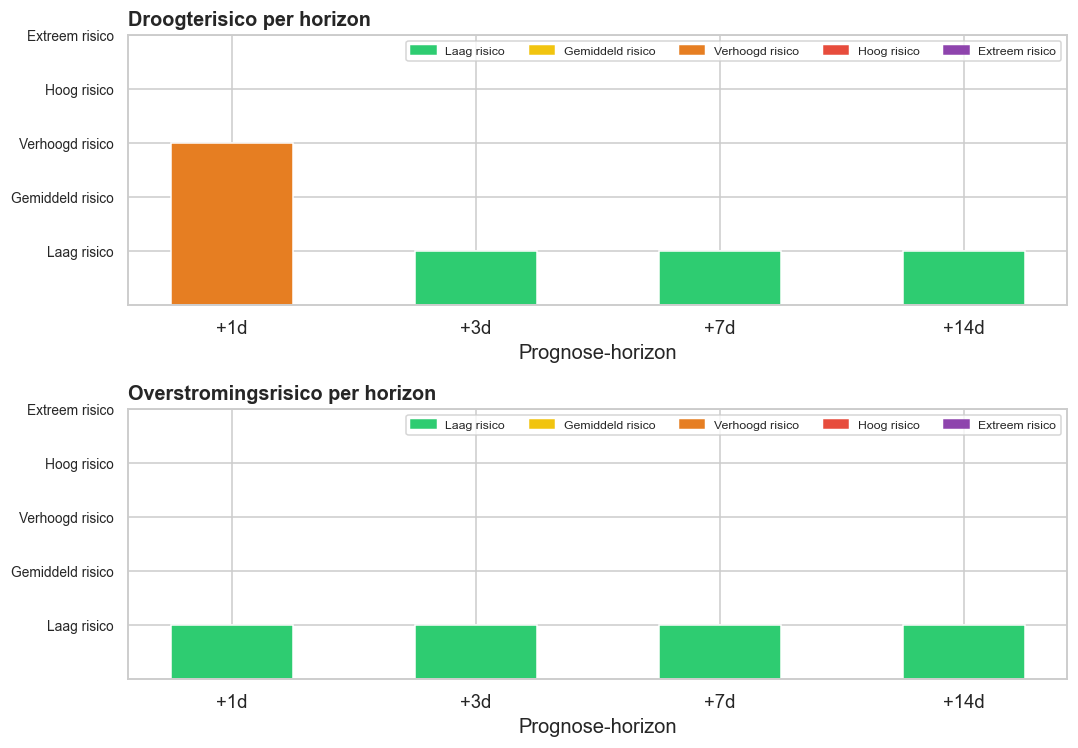

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
horizons_labels = [f"+{h}d" for h in FORECAST_HORIZONS]

# Haal risiconivcaus op als numeriek
drought_nums = []
flood_nums   = []
drought_colors = []
flood_colors   = []
for row in risk_rows:
    dr = next(r for r in RiskLevel if r.value == row["Droogterisico"])
    fr = next(r for r in RiskLevel if r.value == row["Overstromingsrisico"])
    drought_nums.append(dr.numeric + 1)
    flood_nums.append(fr.numeric + 1)
    drought_colors.append(RISK_COLORS[dr])
    flood_colors.append(RISK_COLORS[fr])

for ax, nums, colors, title in [
    (axes[0], drought_nums, drought_colors, "Droogterisico per horizon"),
    (axes[1], flood_nums,   flood_colors,   "Overstromingsrisico per horizon"),
]:
    bars = ax.bar(horizons_labels, nums, color=colors, edgecolor="white", width=0.5)
    ax.set_yticks(range(1, 6))
    ax.set_yticklabels([r.value for r in RiskLevel], fontsize=9)
    ax.set_xlabel("Prognose-horizon")
    ax.set_title(title, fontweight="bold", loc="left")
    ax.legend(handles=RISK_LEGEND, fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("toekomstig_risico.png", bbox_inches="tight")
plt.show()

## 15 · Conclusie – Baselinefase

### Vergelijking van de zes baselinemodellen

| Model | Sterk punt | Beperking |
|-------|-----------|-----------|
| **ARIMA** | Snel, parametrisch, interpreteerbaar | Geen seizoen; fout accumuleert bij langere horizonnen |
| **Holt-Winters** | Vat jaarlijkse cyclus expliciet | Lineaire extrapolatie; kan doorslaan bij abrupte veranderingen |
| **Random Forest** | Niet-lineair, robuust | Recursief: fout stapelt op bij lag_365 voor stap 2–14 |
| **XGBoost** | Lagere bias dan RF door sequentieel boosten | Zelfde recursief probleem; gevoelig voor uitschieters |
| **LSTM** | Leert langetermijngeheugen uit sequenties | Trager te trainen; vereist schaalstap; gevoelig voor hyperparameters |
| **Prophet** | Transparante trend+seizoensdecompositie | Geen auto-regressie; mist dagelijkse turbulentie |

### Aanbeveling voor foundation model-fase
De combinatie van de beste individuele baseline-RMSE's per index vormt de
**benchmark** waaraan het foundation model moet worden getoetst.

Geschikte foundation architecturen:
- **Chronos** (Amazon, nul-shot tijdreeks) – direct bruikbaar zonder extra training.
- **TimesFM** (Google) – fine-tuning op de ERA5-indices.
- **Custom Transformer** met patch-embeddings (PatchTST-stijl) — volledig controleerbaar.

### Beperkingen
- Slechts één ruimtelijk punt; ruimtelijke spreiding ontbreekt.
- Evaluatie is niet rolling-origin; absolute RMSE-waarden zijn te optimistisch voor RF/XGBoost/LSTM.
- ARIMA en HW zijn lineair; extreme events worden onderschat.